# 5. 세분화 성능 — 4구조별 · 기초자산별

통합 모델 하나로 4구조(STEP/LIZARD × 낙인/노낙인)를 모두 커버한다. 전체 R² 만 보면
STEP-낙인이 표본의 약 39%를 차지해 다른 구조의 열화가 가려지므로, **구조별·기초자산별로 쪼개서**
그림으로 확인한다.

- **구조별**: 지표 3종 그룹바 · 예측 산점 2×2 · 오차 분포
- **기초자산별**: 바스켓 조합별 · **개별 지수 포함 여부별** · 지수 × 구조 히트맵
- **시기별**: 구조 × walk-forward 폴드 (시간 안정성)

저장물: `result/image/seg_*.png` (dpi 400·투명·16:9), `result/statistics/seg_*.csv`.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from util import utils, file_manager as fm, plot as _plot
from util.metric import metrics, metrics_by
from module import data, infer

FACE = 10000
cfg = utils.load_config()
D = data.load(cfg)
preds = infer.predict_all_from_weights(D, cfg)

# 구조·기초자산 식별자 (모델 입력이 아니라 평가 분해용)
src = pd.read_parquet(fm.source())[["item", "opt_type", "ki_yn", "udl1", "udl2", "udl3", "udl_key"]].copy()
src["struct"] = src["opt_type"] + " x " + np.where(src["ki_yn"] == 1, "KI", "no-KI")
src = src.rename(columns={"item": "ITEM_CD"}).astype({"ITEM_CD": str}).set_index("ITEM_CD")

fold = np.full(D.n, -1, dtype=int)
for k, (_tr, _va, te) in enumerate(D.WF):
    fold[te] = k
finfo = pd.DataFrame({"ITEM_CD": D.ITEM.astype(str), "fold": fold}).set_index("ITEM_CD")

# 기초자산 티커 → 지수 영어 이름 (그림 라벨 전용. 데이터에는 티커를 그대로 둔다)
TICKER_NAME = {"^GSPC": "S&P 500", "^STOXX50E": "EURO STOXX 50", "^KS200": "KOSPI 200",
               "^N225": "Nikkei 225", "^HSCE": "HSCEI", "^HSI": "Hang Seng",
               "^NDX": "NASDAQ 100", "^GDAXI": "DAX",
               "005930.KS": "Samsung Elec.", "000660.KS": "SK hynix", "051910.KS": "LG Chem",
               "005380.KS": "Hyundai Motor", "005490.KS": "POSCO", "035420.KS": "NAVER",
               "105560.KS": "KB Financial", "006400.KS": "Samsung SDI", "000270.KS": "Kia"}


def uname(t):
    """티커 → 지수 영어 이름. '^' 유무 모두 받고, 미등록 종목은 코드를 그대로 쓴다."""
    t = str(t)
    return TICKER_NAME.get(t) or TICKER_NAME.get("^" + t) or t.replace("^", "")


MODELS = [m for m in ["deeponet_hybrid", "deeponet_hybrid_mape", "deeponet_hybrid_l1",
                      "xgb_hybrid", "bench_xgboost"] if m in preds]
BEST = MODELS[0]                       # 5-1~5-3, 5-5 대표 모델
# 5-4 단계별 그림은 전체 성능이 가장 좋은 MAPE 앵커 기준으로 본다.
# 노트북 전체를 한 모델로 통일하려면 BEST 를 STAGE_MODEL 과 같게 두면 된다.
STAGE_MODEL = "deeponet_hybrid_mape" if "deeponet_hybrid_mape" in preds else BEST

def tidy(name):
    d = preds[name].copy()
    d["ITEM_CD"] = d["ITEM_CD"].astype(str)
    d = d.join(src, on="ITEM_CD").join(finfo, on="ITEM_CD")
    d["err"] = d["y_pred"] - d["y_true"]
    d["ape"] = (d["err"].abs() / d["y_true"].abs()) * 100
    d["model"] = name
    return d

M = pd.concat([tidy(m) for m in MODELS], ignore_index=True)
assert M["struct"].notna().all(), "parquet 조인 실패 (ITEM_CD 불일치)"
STRUCTS = ["STEP x KI", "STEP x no-KI", "LIZARD x KI", "LIZARD x no-KI"]
STRUCTS = [s for s in STRUCTS if s in set(M["struct"])]
print(f"모델 {len(MODELS)} | OOS {len(preds[BEST]):,}행 | 대표 모델 {BEST} | 단계별 그림 {STAGE_MODEL}")
print(M.groupby("struct")["ITEM_CD"].nunique().to_string())

모델 5 | OOS 23,516행 | 대표 모델 deeponet_hybrid | 단계별 그림 deeponet_hybrid_mape
struct
LIZARD x KI         655
LIZARD x no-KI     1858
STEP x KI          8708
STEP x no-KI      12295


## 5-1. 구조별 성능

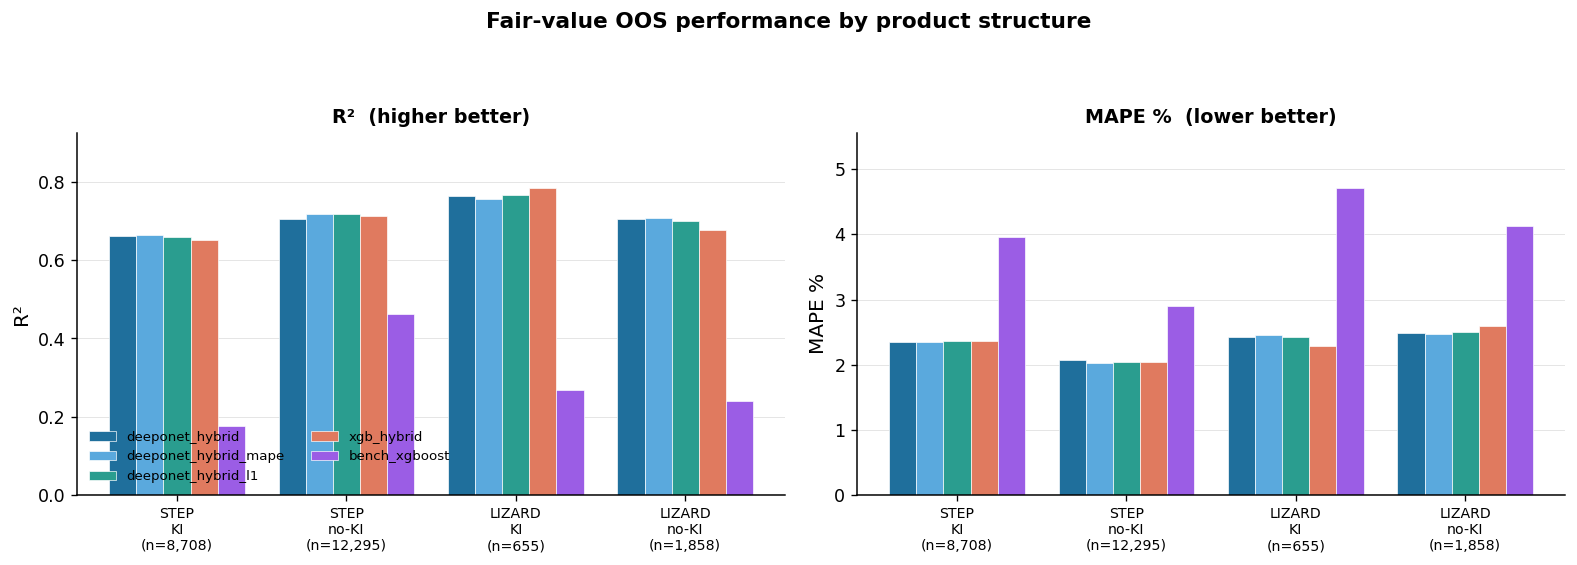

               model         struct     n     R2   MAPE
     deeponet_hybrid      STEP x KI  8708 0.6610 2.3549
     deeponet_hybrid   STEP x no-KI 12295 0.7041 2.0764
     deeponet_hybrid    LIZARD x KI   655 0.7632 2.4210
     deeponet_hybrid LIZARD x no-KI  1858 0.7047 2.4920
deeponet_hybrid_mape      STEP x KI  8708 0.6646 2.3461
deeponet_hybrid_mape   STEP x no-KI 12295 0.7184 2.0236
deeponet_hybrid_mape    LIZARD x KI   655 0.7572 2.4581
deeponet_hybrid_mape LIZARD x no-KI  1858 0.7086 2.4706
  deeponet_hybrid_l1      STEP x KI  8708 0.6600 2.3575
  deeponet_hybrid_l1   STEP x no-KI 12295 0.7169 2.0387
  deeponet_hybrid_l1    LIZARD x KI   655 0.7667 2.4208
  deeponet_hybrid_l1 LIZARD x no-KI  1858 0.7006 2.5054
          xgb_hybrid      STEP x KI  8708 0.6522 2.3705
          xgb_hybrid   STEP x no-KI 12295 0.7135 2.0403
          xgb_hybrid    LIZARD x KI   655 0.7850 2.2931
          xgb_hybrid LIZARD x no-KI  1858 0.6779 2.5931
       bench_xgboost      STEP x KI  8708 0.1772

In [2]:
# 그림 1: 구조별 R² · MAPE — 모델 그룹바
from sklearn.metrics import r2_score

rows = []
for name in MODELS:
    d0 = M[M.model == name]
    for s in STRUCTS:
        g = d0[d0.struct == s]
        rows.append(dict(model=name, struct=s, n=len(g), R2=r2_score(g.y_true, g.y_pred),
                         MAPE=g.ape.mean(), BiasKRW=g.err.mean() * FACE))
S = pd.DataFrame(rows)
S.to_csv(fm.stat("seg_structure"), index=False)

XL = [s.replace(" x ", "\n") + f"\n(n={int(S[S.struct==s].n.iloc[0]):,})" for s in STRUCTS]
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 4.8))
x = np.arange(len(STRUCTS)); w = 0.8 / len(MODELS)
for j, name in enumerate(MODELS):
    v = S[S.model == name].set_index("struct").loc[STRUCTS]
    off = (j - (len(MODELS) - 1) / 2) * w
    c = _plot._QUAL[j % len(_plot._QUAL)]
    ax[0].bar(x + off, v["R2"].values, w, label=name, color=c, edgecolor="white", linewidth=0.4)
    ax[1].bar(x + off, v["MAPE"].values, w, label=name, color=c, edgecolor="white", linewidth=0.4)
for a, lab, ttl in ((ax[0], "R²", "R²  (higher better)"),
                    (ax[1], "MAPE %", "MAPE %  (lower better)")):
    a.set_xticks(x); a.set_xticklabels(XL, fontsize=8.5)
    a.axhline(0, color="#444", lw=0.7); a.set_ylabel(lab); a.set_title(ttl, fontsize=11.5)
    a.grid(axis="y", color="#cccccc", lw=0.6, alpha=0.5); a.margins(y=0.18)
ax[0].legend(fontsize=8, ncol=2, loc="lower left")
fig.suptitle("Fair-value OOS performance by product structure", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(fm.image("seg_structure_metrics"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print(S[["model", "struct", "n", "R2", "MAPE"]].round(4).to_string(index=False))
print("saved ->", fm.image("seg_structure_metrics").name, "|", fm.stat("seg_structure").name)

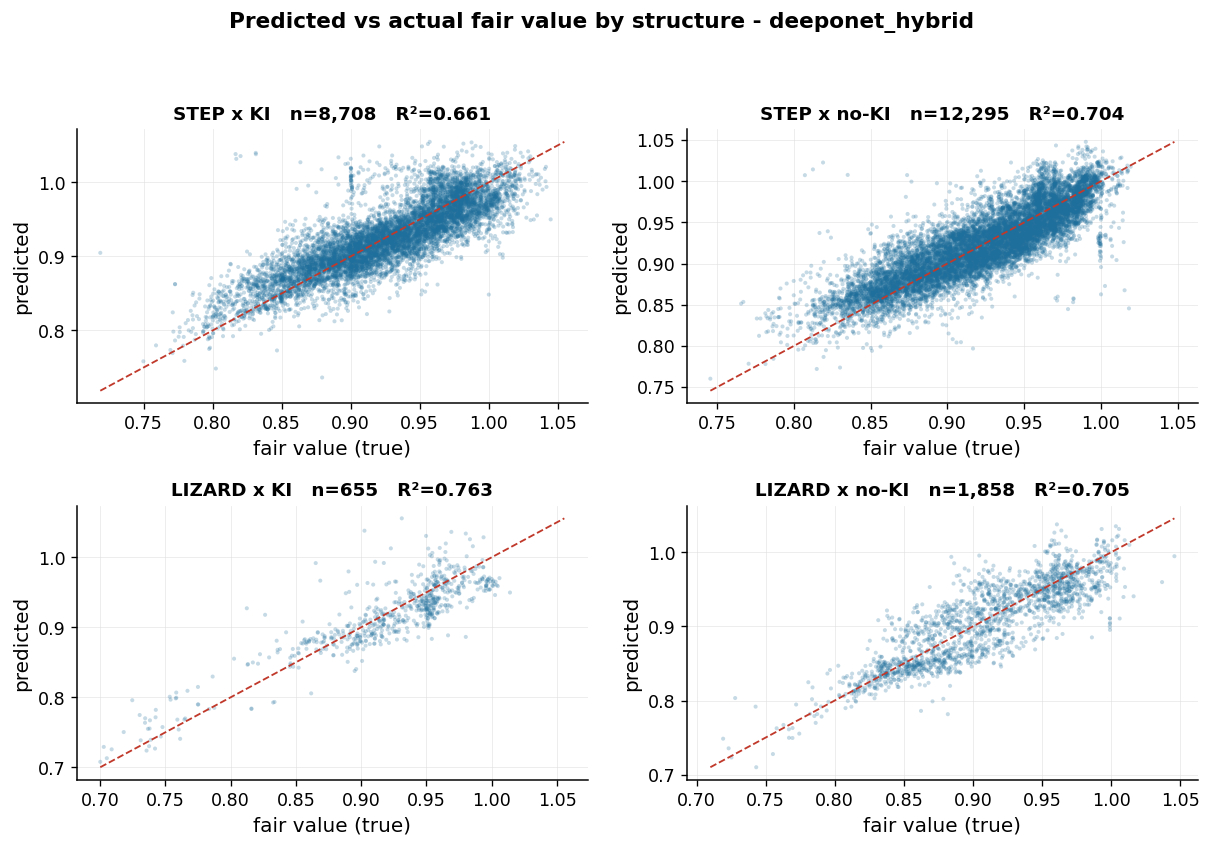

saved -> seg_structure_scatter.png


In [3]:
# 그림 2: 구조별 예측 vs 실제 산점 (대표 모델)
d = M[M.model == BEST]
fig, axs = plt.subplots(2, 2, figsize=(_plot.SLIDE_W * 0.78, 7.2))
for a, s in zip(axs.ravel(), STRUCTS):
    g = d[d.struct == s]
    lim = [min(g.y_true.min(), g.y_pred.min()), max(g.y_true.max(), g.y_pred.max())]
    a.scatter(g.y_true, g.y_pred, s=6, alpha=0.25, color="#1f6f9c", edgecolors="none")
    a.plot(lim, lim, "--", color="#c0392b", lw=1.1)
    a.set_title(f"{s}   n={len(g):,}   R²={r2_score(g.y_true, g.y_pred):.3f}", fontsize=11)
    a.set_xlabel("fair value (true)"); a.set_ylabel("predicted")
    a.grid(color="#dddddd", lw=0.5, alpha=0.6)
for a in axs.ravel()[len(STRUCTS):]:
    a.axis("off")
fig.suptitle(f"Predicted vs actual fair value by structure - {BEST}", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(fm.image("seg_structure_scatter"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("saved ->", fm.image("seg_structure_scatter").name)

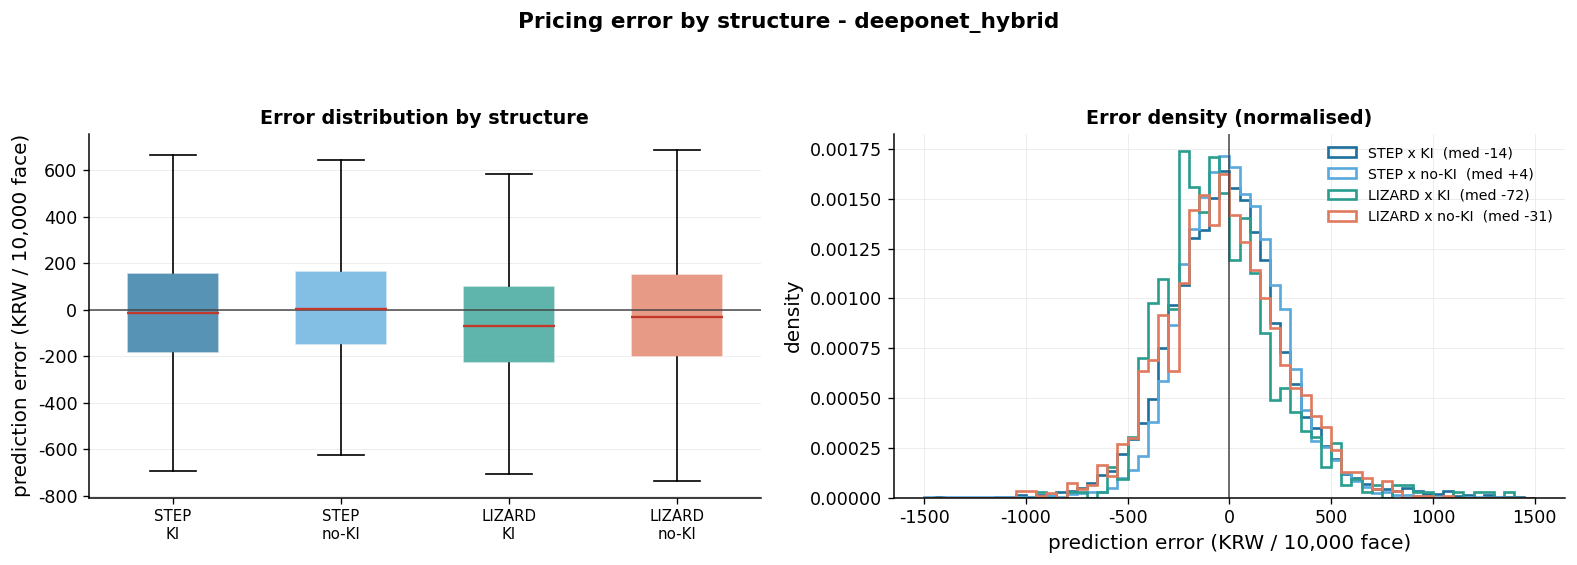

saved -> seg_structure_error.png


In [4]:
# 그림 3: 구조별 오차 분포 (원 단위) — 박스 + 개별 점 일부
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 4.8))
dat = [d[d.struct == s].err.values * FACE for s in STRUCTS]
bp = ax[0].boxplot(dat, vert=True, patch_artist=True, showfliers=False,
                   medianprops=dict(color="#c0392b", lw=1.4), widths=0.55)
for patch, c in zip(bp["boxes"], _plot._QUAL):
    patch.set_facecolor(c); patch.set_alpha(0.75); patch.set_edgecolor("white")
ax[0].axhline(0, color="#444", lw=0.9)
ax[0].set_xticklabels([s.replace(" x ", "\n") for s in STRUCTS], fontsize=9)
ax[0].set_ylabel("prediction error (KRW / 10,000 face)")
ax[0].set_title("Error distribution by structure", fontsize=11.5)
ax[0].grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6)

for j, s in enumerate(STRUCTS):
    e = d[d.struct == s].err.values * FACE
    ax[1].hist(e, bins=60, range=(-1500, 1500), histtype="step", linewidth=1.6,
               color=_plot._QUAL[j], label=f"{s}  (med {np.median(e):+.0f})", density=True)
ax[1].axvline(0, color="#444", lw=0.9)
ax[1].set_xlabel("prediction error (KRW / 10,000 face)"); ax[1].set_ylabel("density")
ax[1].set_title("Error density (normalised)", fontsize=11.5)
ax[1].legend(fontsize=8.5); ax[1].grid(color="#dddddd", lw=0.5, alpha=0.6)

fig.suptitle(f"Pricing error by structure - {BEST}", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(fm.image("seg_structure_error"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("saved ->", fm.image("seg_structure_error").name)

## 5-2. 기초자산별 성능

바스켓 **조합**(3개 묶음)과 **개별 지수 포함 여부**를 나눠서 본다. 후자는 한 상품이 3개 지수에
각각 계상되므로 합계가 표본 수를 넘는다 — "그 지수가 들어간 상품의 성능"으로 읽어야 한다.

### 기초자산 지수 약어

3-star 상품은 아래 중 **3개를 worst-of** 로 묶는다 (가장 많이 빠진 자산이 상환·낙인을 결정).

| 티커 | 지수 | 지역 | 비고 |
|---|---|---|---|
| `^KS200` | KOSPI 200 | 한국 | 코스피 시가총액 상위 200종목 |
| `^GSPC` | S&P 500 | 미국 | |
| `^STOXX50E` | EURO STOXX 50 | 유로존 | 표본에서 가장 많이 쓰인 기초자산 |
| `^HSCE` | HSCEI (Hang Seng China Enterprises) | 홍콩·중국 | 홍콩 상장 중국 본토기업(H주). 2015·2021 급락으로 낙인 사태를 일으킨 그 지수 |
| `^HSI` | Hang Seng Index | 홍콩 | HSCEI 와 상관 0.96 로 사실상 같이 움직인다 |
| `^N225` | Nikkei 225 | 일본 | |
| `^NDX` | NASDAQ-100 | 미국 | 소수 |
| `^GDAXI` | DAX | 독일 | 소수 |
| `005930.KS` | 삼성전자 | 한국 | 지수가 아닌 **개별종목** |
| `000660.KS` | SK하이닉스 | 한국 | 개별종목 |

개별종목(삼성전자·SK하이닉스)이 낀 상품은 표본이 작고(각 451·362건) 변동성이 지수보다 훨씬 커서
아래 지수별 판에서 따로 읽어야 한다.

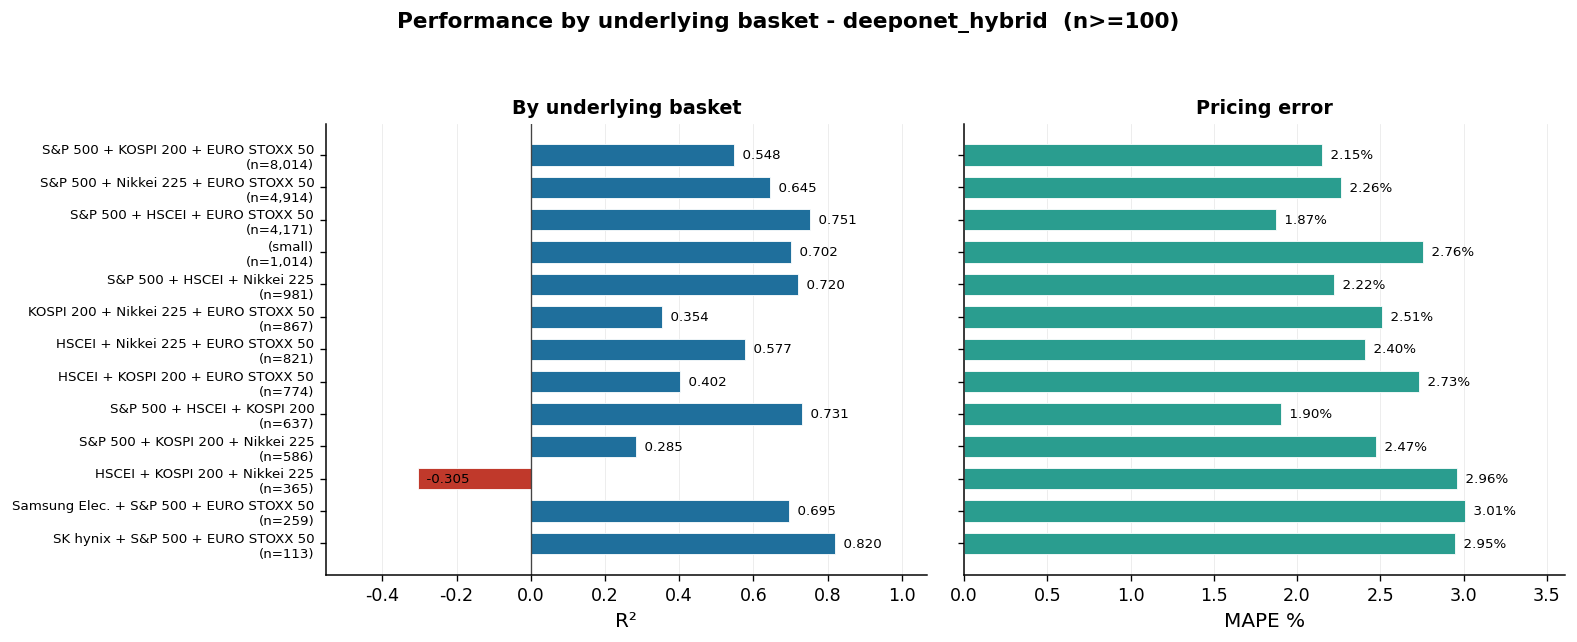

                              n      R2   MAPE%   Bias%
^GSPC|^KS200|^STOXX50E     8014  0.5482  2.1482  0.2453
^GSPC|^N225|^STOXX50E      4914  0.6448  2.2619  0.4151
^GSPC|^HSCE|^STOXX50E      4171  0.7514  1.8746  0.2159
(small)                    1014  0.7016  2.7591 -0.5103
^GSPC|^HSCE|^N225           981  0.7197  2.2238  0.0603
^KS200|^N225|^STOXX50E      867  0.3541  2.5118 -0.7063
^HSCE|^N225|^STOXX50E       821  0.5772  2.4048 -1.2399
^HSCE|^KS200|^STOXX50E      774  0.4025  2.7310 -0.5482
^GSPC|^HSCE|^KS200          637  0.7315  1.9040 -0.8688
^GSPC|^KS200|^N225          586  0.2848  2.4749 -0.7987
^HSCE|^KS200|^N225          365 -0.3048  2.9618 -0.6346
005930.KS|^GSPC|^STOXX50E   259  0.6954  3.0084  1.6945
000660.KS|^GSPC|^STOXX50E   113  0.8203  2.9488  1.6496
saved -> seg_underlying_basket.png


In [5]:
# 그림 4: 바스켓 조합별 R² · MAPE (표본 100건 이상)
BU = {name: metrics_by(M[M.model == name].y_true, M[M.model == name].y_pred,
                       M[M.model == name].udl_key, min_n=100) for name in MODELS}
pd.concat(BU, names=["model", "group"]).to_csv(fm.stat("seg_underlying_basket"))
U = BU[BEST].sort_values("n", ascending=False)
lab = [f"{' + '.join(uname(x) for x in i.split('|'))}\n(n={int(v):,})" for i, v in zip(U.index, U["n"])]

fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, max(4.6, 0.42 * len(U))))
y = np.arange(len(U))
cols = ["#c0392b" if r < 0 else "#1f6f9c" for r in U["R2"]]
ax[0].barh(y, U["R2"].values, height=0.66, color=cols, edgecolor="white", linewidth=0.5)
ax[0].set_yticks(y); ax[0].set_yticklabels(lab, fontsize=8); ax[0].invert_yaxis()
ax[0].axvline(0, color="#444", lw=0.8)
for i, v in enumerate(U["R2"].values):
    ax[0].text(v, i, f"  {v:.3f}", va="center", fontsize=8)
ax[0].set_xlabel("R²"); ax[0].set_title("By underlying basket", fontsize=11.5)
ax[0].grid(axis="x", color="#dddddd", lw=0.5, alpha=0.6); ax[0].margins(x=0.22)

ax[1].barh(y, U["MAPE%"].values, height=0.66, color="#2a9d8f", edgecolor="white", linewidth=0.5)
ax[1].set_yticks(y); ax[1].set_yticklabels([]); ax[1].invert_yaxis()
for i, v in enumerate(U["MAPE%"].values):
    ax[1].text(v, i, f"  {v:.2f}%", va="center", fontsize=8)
ax[1].set_xlabel("MAPE %"); ax[1].set_title("Pricing error", fontsize=11.5)
ax[1].grid(axis="x", color="#dddddd", lw=0.5, alpha=0.6); ax[1].margins(x=0.20)

fig.suptitle(f"Performance by underlying basket - {BEST}  (n>=100)", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(fm.image("seg_underlying_basket"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print(U[["n", "R2", "MAPE%", "Bias%"]].round(4).to_string())
print("saved ->", fm.image("seg_underlying_basket").name)

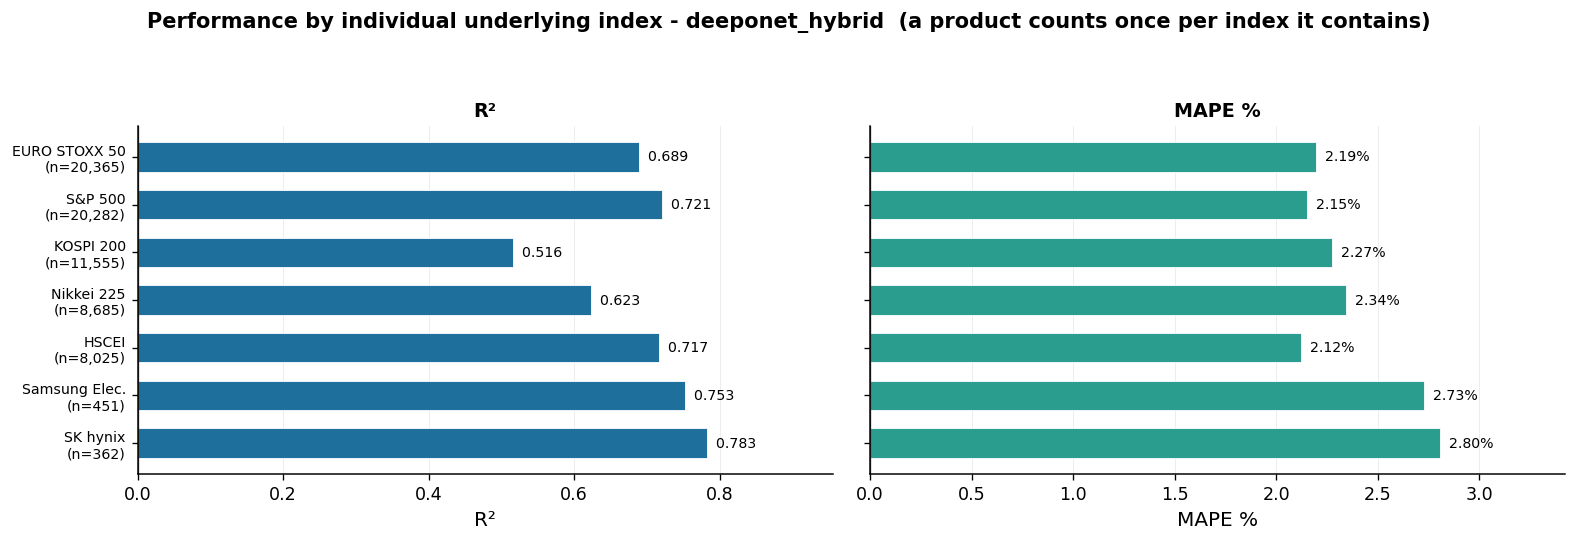

   ticker          name     n     R2   MAPE    BiasKRW
^STOXX50E EURO STOXX 50 20365 0.6888 2.1950   8.470500
    ^GSPC       S&P 500 20282 0.7206 2.1516  15.174900
   ^KS200     KOSPI 200 11555 0.5162 2.2746  -9.353500
    ^N225    Nikkei 225  8685 0.6229 2.3443  -9.801800
    ^HSCE         HSCEI  8025 0.7168 2.1205 -21.594299
005930.KS Samsung Elec.   451 0.7529 2.7281  55.501701
000660.KS      SK hynix   362 0.7830 2.8046  35.205601
saved -> seg_underlying_ticker.png


In [6]:
# 그림 5: 개별 지수 포함 여부별 R² · MAPE (한 상품이 3개 지수에 계상됨)
def by_ticker(d0, min_n=200):
    tk = pd.unique(pd.concat([d0.udl1, d0.udl2, d0.udl3]).dropna())
    out = []
    for t in tk:
        g = d0[(d0.udl1 == t) | (d0.udl2 == t) | (d0.udl3 == t)]
        if len(g) < min_n:
            continue
        out.append(dict(ticker=t, name=uname(t), n=len(g), R2=r2_score(g.y_true, g.y_pred),
                        MAPE=g.ape.mean(), BiasKRW=g.err.mean() * FACE))
    return pd.DataFrame(out).sort_values("n", ascending=False).reset_index(drop=True)

T = by_ticker(M[M.model == BEST])
pd.concat({name: by_ticker(M[M.model == name]) for name in MODELS},
          names=["model", "i"]).to_csv(fm.stat("seg_underlying_ticker"))

fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, max(4.6, 0.5 * len(T))))
y = np.arange(len(T))
YL = [f"{t}\n(n={int(nn):,})" for t, nn in zip(T.name, T.n)]
for a, col, lab, cmapc in ((ax[0], "R2", "R²", None), (ax[1], "MAPE", "MAPE %", "#2a9d8f")):
    v = T[col].values
    c = ["#c0392b" if x < 0 else "#1f6f9c" for x in v] if cmapc is None else cmapc
    a.barh(y, v, height=0.62, color=c, edgecolor="white", linewidth=0.5)
    a.set_yticks(y); a.set_yticklabels(YL if a is ax[0] else [], fontsize=8.5)
    a.invert_yaxis(); a.axvline(0, color="#444", lw=0.8)
    fmt = "  {:.3f}" if col == "R2" else "  {:.2f}%"
    for i, x in enumerate(v):
        a.text(x, i, fmt.format(x), va="center", fontsize=8.5)
    a.set_xlabel(lab); a.set_title(lab, fontsize=11.5)
    a.grid(axis="x", color="#dddddd", lw=0.5, alpha=0.6); a.margins(x=0.22)
fig.suptitle(f"Performance by individual underlying index - {BEST}"
             "  (a product counts once per index it contains)", fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(fm.image("seg_underlying_ticker"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print(T.round(4).to_string(index=False))
print("saved ->", fm.image("seg_underlying_ticker").name)

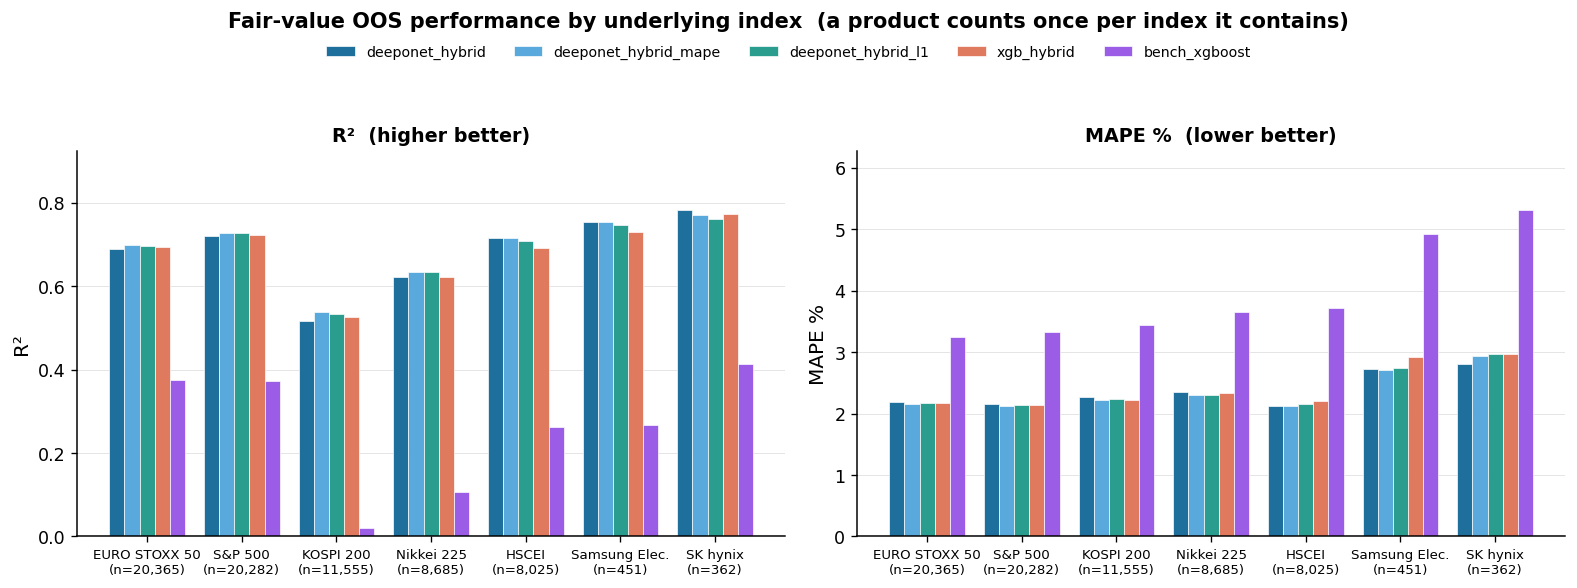

model          bench_xgboost  deeponet_hybrid  deeponet_hybrid_l1  deeponet_hybrid_mape  xgb_hybrid
ticker                                                                                             
EURO STOXX 50         0.3754           0.6888              0.6964                0.6980      0.6942
S&P 500               0.3733           0.7206              0.7268                0.7281      0.7217
KOSPI 200             0.0198           0.5162              0.5322                0.5379      0.5268
Nikkei 225            0.1067           0.6229              0.6341                0.6348      0.6230
HSCEI                 0.2624           0.7168              0.7074                0.7157      0.6909
Samsung Elec.         0.2674           0.7529              0.7479                0.7542      0.7304
SK hynix              0.4127           0.7830              0.7610                0.7697      0.7727
saved -> seg_underlying_metrics.png | seg_underlying_metrics.csv


In [7]:
# 그림 5b: 기초자산 지수별 R² · MAPE — 모델 그룹바 (그림 1 의 구조별 판과 같은 형식)
TK = list(T.ticker)                                     # 그림 5 에서 만든 대표 모델 기준 순서(표본 내림차순)
rows = []
for name in MODELS:
    d0 = M[M.model == name]
    for t in TK:
        g = d0[(d0.udl1 == t) | (d0.udl2 == t) | (d0.udl3 == t)]
        if not len(g):
            continue
        rows.append(dict(model=name, ticker=t, n=len(g), R2=r2_score(g.y_true, g.y_pred),
                         MAPE=g.ape.mean(), BiasKRW=g.err.mean() * FACE))
UM = pd.DataFrame(rows)
UM.to_csv(fm.stat("seg_underlying_metrics"), index=False)

XL = [f"{uname(t)}\n(n={int(UM[UM.ticker == t].n.iloc[0]):,})" for t in TK]
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 5.0))
x = np.arange(len(TK)); w = 0.8 / len(MODELS)
for j, name in enumerate(MODELS):
    v = UM[UM.model == name].set_index("ticker").reindex(TK)
    off = (j - (len(MODELS) - 1) / 2) * w
    c = _plot._QUAL[j % len(_plot._QUAL)]
    ax[0].bar(x + off, v["R2"].values, w, label=name, color=c, edgecolor="white", linewidth=0.4)
    ax[1].bar(x + off, v["MAPE"].values, w, label=name, color=c, edgecolor="white", linewidth=0.4)
for a, lab, ttl in ((ax[0], "R²", "R²  (higher better)"),
                    (ax[1], "MAPE %", "MAPE %  (lower better)")):
    a.set_xticks(x); a.set_xticklabels(XL, fontsize=8)
    a.axhline(0, color="#444", lw=0.7); a.set_ylabel(lab); a.set_title(ttl, fontsize=11.5)
    a.grid(axis="y", color="#cccccc", lw=0.6, alpha=0.5); a.margins(y=0.18)
h, l = ax[0].get_legend_handles_labels()
fig.legend(h, l, loc="upper center", ncol=len(MODELS), bbox_to_anchor=(0.5, 0.945),
           fontsize=8.5, frameon=False)
fig.suptitle("Fair-value OOS performance by underlying index"
             "  (a product counts once per index it contains)", fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.savefig(fm.image("seg_underlying_metrics"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
_p = UM.pivot(index="ticker", columns="model", values="R2").reindex(TK)
print(_p.rename(index=uname).round(4).to_string())
print("saved ->", fm.image("seg_underlying_metrics").name, "|", fm.stat("seg_underlying_metrics").name)

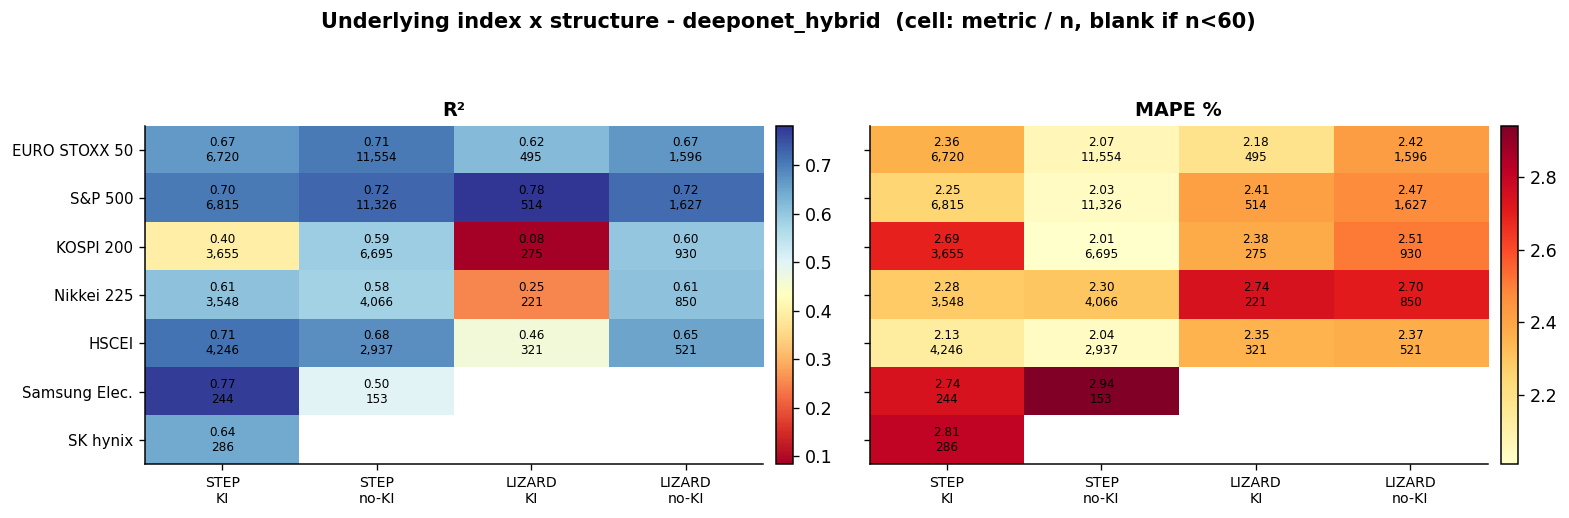

saved -> seg_underlying_x_structure.png


In [8]:
# 그림 6: 지수 × 구조 히트맵 (R² 와 MAPE%)
TK = list(T.ticker)
H_r2 = np.full((len(TK), len(STRUCTS)), np.nan)
H_mp = np.full((len(TK), len(STRUCTS)), np.nan)
H_n = np.zeros((len(TK), len(STRUCTS)), int)
for i, t in enumerate(TK):
    for j, s in enumerate(STRUCTS):
        g = d[(d.struct == s) & ((d.udl1 == t) | (d.udl2 == t) | (d.udl3 == t))]
        H_n[i, j] = len(g)
        if len(g) >= 60:
            H_r2[i, j] = r2_score(g.y_true, g.y_pred); H_mp[i, j] = g.ape.mean()

fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, max(4.4, 0.5 * len(TK))))
for a, H, lab, cmap in [(ax[0], H_r2, "R²", "RdYlBu"), (ax[1], H_mp, "MAPE %", "YlOrRd")]:
    im = a.imshow(H, aspect="auto", cmap=cmap)
    a.set_xticks(range(len(STRUCTS)))
    a.set_xticklabels([s.replace(" x ", "\n") for s in STRUCTS], fontsize=8.5)
    a.set_yticks(range(len(TK)))
    a.set_yticklabels([uname(t) for t in TK] if a is ax[0] else [], fontsize=9)
    for i in range(len(TK)):
        for j in range(len(STRUCTS)):
            if not np.isnan(H[i, j]):
                a.text(j, i, f"{H[i,j]:.2f}\n{H_n[i,j]:,}", ha="center", va="center", fontsize=7.2)
    a.set_title(lab, fontsize=11.5)
    fig.colorbar(im, ax=a, fraction=0.046, pad=0.02)
fig.suptitle(f"Underlying index x structure - {BEST}  (cell: metric / n, blank if n<60)",
             fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(fm.image("seg_underlying_x_structure"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
assert H_n.sum() > 0, "히트맵 티커 매칭 실패 (T.ticker 와 udl1..3 형식 불일치)"
print("saved ->", fm.image("seg_underlying_x_structure").name)

## 5-3. 시기별 안정성 (walk-forward 폴드 × 구조)

폴드 0 은 train 이 가장 적고(60%) 그 test 구간이 HSCEI 급락 직전이라, 학습에 없던 국면으로
외삽하게 된다. 구조별로도 같은 패턴인지 확인한다.

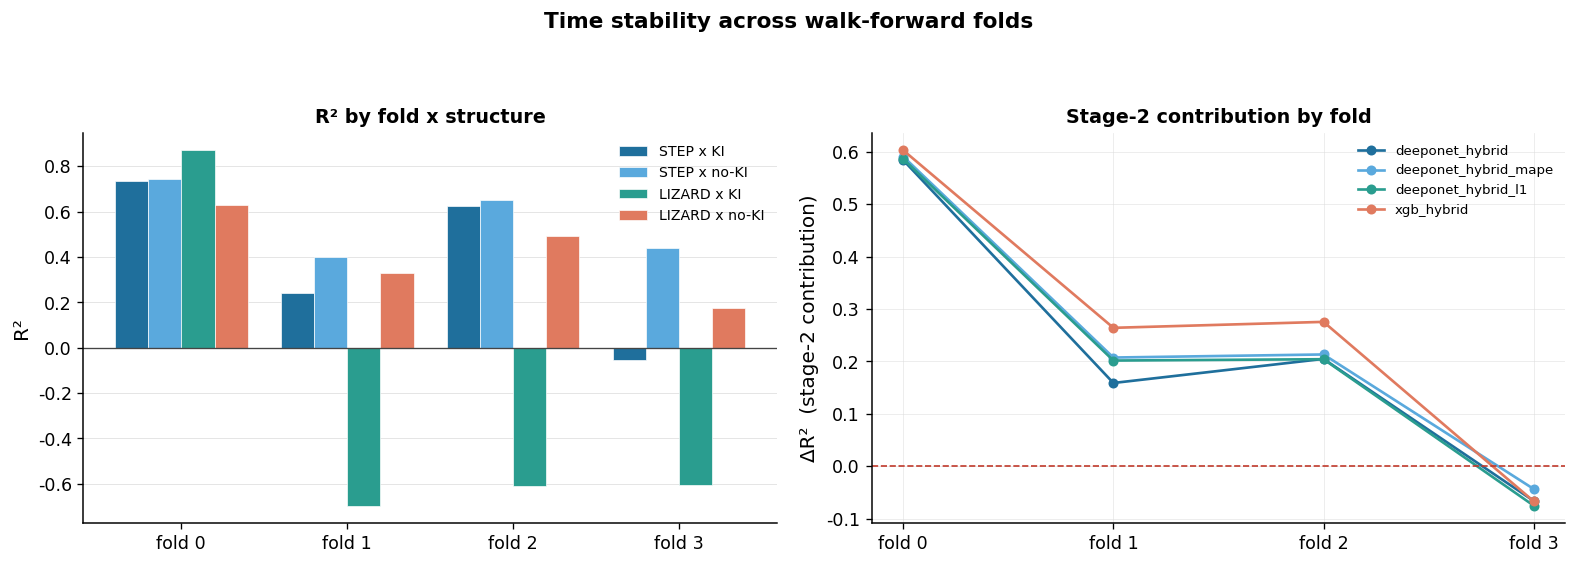

saved -> seg_fold_stability.png


In [9]:
# 그림 7: 폴드 × 구조 R² + stage2 기여
nf = len(D.WF)
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 4.8))
x = np.arange(nf); w = 0.8 / max(len(STRUCTS), 1)
for j, s in enumerate(STRUCTS):
    v, lb = [], []
    for k in range(nf):
        g = d[(d.struct == s) & (d.fold == k)]
        v.append(r2_score(g.y_true, g.y_pred) if len(g) > 30 else np.nan)
        lb.append(len(g))
    ax[0].bar(x + (j - (len(STRUCTS) - 1) / 2) * w, v, w, label=s,
              color=_plot._QUAL[j], edgecolor="white", linewidth=0.4)
ax[0].set_xticks(x); ax[0].set_xticklabels([f"fold {k}" for k in range(nf)])
ax[0].axhline(0, color="#444", lw=0.8); ax[0].set_ylabel("R²")
ax[0].set_title("R² by fold x structure", fontsize=11.5)
ax[0].legend(fontsize=8.5); ax[0].grid(axis="y", color="#cccccc", lw=0.6, alpha=0.5)

# stage2 기여 = R2(최종) - R2(MC_hat + margin)
for j, name in enumerate(MODELS):
    dd = M[M.model == name]
    if "resid_pred" not in dd.columns or dd["resid_pred"].isna().all():
        continue
    con = []
    for k in range(nf):
        g = dd[dd.fold == k]
        base = g.y_pred - g.resid_pred
        con.append(r2_score(g.y_true, g.y_pred) - r2_score(g.y_true, base))
    ax[1].plot(x, con, "o-", lw=1.6, ms=5, color=_plot._QUAL[j % len(_plot._QUAL)], label=name)
ax[1].axhline(0, color="#c0392b", lw=1.0, ls="--")
ax[1].set_xticks(x); ax[1].set_xticklabels([f"fold {k}" for k in range(nf)])
ax[1].set_ylabel("ΔR²  (stage-2 contribution)")
ax[1].set_title("Stage-2 contribution by fold", fontsize=11.5)
ax[1].legend(fontsize=8); ax[1].grid(color="#dddddd", lw=0.5, alpha=0.6)

fig.suptitle("Time stability across walk-forward folds", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(fm.image("seg_fold_stability"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("saved ->", fm.image("seg_fold_stability").name)

## 5-4. 단계별(stage) 성능 분해 — 상품 구조별 · 기초자산별

하이브리드는 두 단계다.

```
Fair_hat = MC_hat(stage-1: DeepONet 이 MC 이론가 근사) + recent_margin + Residual_hat(stage-2: 마진 잔차)
```

- **stage-1**: `R²(MC, MC_hat)` — 연산자망이 이론가를 얼마나 재현하나 (이론 파트)
- **stage-2**: `R²(resid, resid_hat)`, `resid = Fair − MC_hat − recent_margin` — 시장 마진을 얼마나 설명하나
- **final**: `R²(Fair, Fair_hat)`

**오차 정의**: R² 가 각 단계를 **자기 타깃의 분산**으로 나누듯, 오차도 **자기 타깃의 크기**로 나눈다.

```
RELown_s = mean|pred_s − target_s| / mean|target_s| × 100     (s = stage1 / stage2 / final)
```

per-row 나눗셈(표준 MAPE)은 잔차가 0 을 넘나들어 발산하므로 **집계비**(평균 오차 ÷ 평균 타깃)를 쓴다.
stage-1·final 은 타깃이 1 근처에 몰려 있어 표준 MAPE 와 소수점 둘째 자리까지 같고, stage-2 만 자기 몫이 드러난다.

| 단계 | mean&#124;오차&#124; | mean&#124;타깃&#124; | RELown |
|---|---|---|---|
| stage-1 (MC 앵커) | 30원 | 9,862원 | **0.31%** |
| stage-2 (마진 잔차) | 201원 | **264원** | **76.1%** |
| final (공정가) | 201원 | 9,230원 | **2.18%** |

**오차(201원)는 stage-2 와 final 이 같다** — `resid = Fair − MC_hat − rm`, `Fair_hat = MC_hat + rm + resid_hat`
이므로 `Fair_hat − Fair ≡ resid_hat − resid` 이기 때문이다. 하지만 **나누는 대상이 다르다**:
final 은 9,230원짜리 공정가를 2.18% 오차로 맞힌 것이고, stage-2 는 264원짜리 마진을 76% 오차로 맞힌 것이다.
**둘 다 사실이고, 후자가 이 모델의 진짜 난이도다.** 세 값의 범위가 0.2%~96% 로 넓어 오차 패널은 **로그축**을 쓴다.

공정가 분모로 통일한 값(`stage*_MAPE`, stage-2 = final)도 CSV 에 함께 저장한다.

> **R² 읽을 때 주의**: `R² = 1 − MSE/Var(target)` 이라 **타깃 분산이 다른 세그먼트끼리 R² 를 직접 비교하면 오해**한다.
> LIZARD×KI 와 STEP×KI 는 RMSE 가 288 vs 290원으로 사실상 같은데 R² 는 0.76 vs 0.66 이다 —
> 차이는 공정가 표준편차(592 vs 498원)뿐이다. 아래 세 번째 패널이 그 관계를 직접 보인다.

**stage-2 오차 = final 오차 (항등식)**: `resid = Fair − MC_hat − rm` 이고 `Fair_hat = MC_hat + rm + resid_hat`
이므로 `Fair_hat − Fair ≡ resid_hat − resid` 다. 두 단계의 **오차는 같은 값**이고, R² 만 분모가 다르다
(stage-2 는 `Var(resid)`, final 은 `Var(Fair)`).

그래서 MAPE 패널도 R² 패널과 **똑같이 3막대**로 그리되, **stage-2 막대와 final 막대는 항등식에 의해 높이가 같다**.
이건 오류가 아니라 결과다 — **공정가 오차는 전부 stage-2 에서 나온다**는 뜻이고, stage-1(이론가 재현)의
기여분은 그 왼쪽 막대가 얼마나 낮은지로 읽는다. stage-2 가 잔차 분산을 얼마나 설명했는지는 R² 패널에서 본다.

In [10]:
# 단계별 지표 (구조별 · 기초자산별) — R², MAPE(공정가 분모), 표준 MAPE, RMSE(원)
from sklearn.metrics import r2_score

HYB = [m for m in MODELS if "mc_pred" in preds[m].columns]      # 2단계 모델만 (직접 벤치마크 제외)
STAGES = [("stage1", "mc_true", "mc_pred", "MC anchor"),
          ("stage2", "resid_true", "resid_pred", "margin residual"),
          ("final", "y_true", "y_pred", "fair value")]


def _stage_metrics(sub):
    """세 단계 지표.
     RELown = mean|오차| / mean|자기 타깃| — R² 와 같은 규칙(각 단계를 자기 타깃 크기로 정규화).
              per-row 나눗셈은 잔차가 0 을 넘나들어 발산하므로 집계비를 쓴다.
     MAPE   = mean(|오차| / 공정가) — 분모를 공정가로 통일한 값(항등식 때문에 stage2 = final)."""
    fair = sub["y_true"].abs().values
    row = {}
    for sname, tc, pc, _ in STAGES:
        e = np.abs((sub[pc] - sub[tc]).values)
        row[f"{sname}_R2"] = r2_score(sub[tc], sub[pc])
        row[f"{sname}_RELown"] = float(e.mean() / sub[tc].abs().mean() * 100)  # 자기 타깃 분모
        row[f"{sname}_MAPE"] = float((e / fair).mean() * 100)                  # 공통 분모 = 공정가
        row[f"{sname}_MTGT"] = float(sub[tc].abs().mean() * FACE)              # mean|타깃| (원)
        row[f"{sname}_RMSE"] = float(np.sqrt((e ** 2).mean()) * FACE)
        row[f"{sname}_SD"] = float(sub[tc].std() * FACE)
    return row


def stage_table(d, group_col, min_n=30):
    out = []
    for g, sub in d.groupby(group_col):
        if len(sub) < min_n:
            continue
        out.append({"group": g, "n": len(sub), **_stage_metrics(sub)})
    return pd.DataFrame(out).set_index("group")


def stage_table_ticker(d, min_n=200):
    tk = pd.unique(pd.concat([d.udl1, d.udl2, d.udl3]).dropna())
    out = []
    for t in tk:
        sub = d[(d.udl1 == t) | (d.udl2 == t) | (d.udl3 == t)]
        if len(sub) < min_n:
            continue
        out.append({"group": uname(t), "n": len(sub), **_stage_metrics(sub)})
    return pd.DataFrame(out).sort_values("n", ascending=False).set_index("group")


ST = {m: stage_table(M[M.model == m], "struct") for m in HYB}
UT = {m: stage_table_ticker(M[M.model == m]) for m in HYB}
pd.concat(ST, names=["model", "group"]).to_csv(fm.stat("seg_stage_structure"))
pd.concat(UT, names=["model", "group"]).to_csv(fm.stat("seg_stage_underlying"))

SHOW = ["n", "stage1_R2", "stage2_R2", "final_R2",
        "stage1_RELown", "stage2_RELown", "final_RELown", "final_MAPE"]
print(f"=== 상품 구조별 단계 지표 — {STAGE_MODEL}  (RELown 분모 = 각 단계 자기 타깃) ===")
print(ST[STAGE_MODEL].reindex(STRUCTS)[SHOW].round(4).to_string())
print(f"\n=== 기초자산 지수별 단계 지표 — {STAGE_MODEL} ===")
print(UT[STAGE_MODEL][SHOW].round(4).to_string())
print("\nsaved ->", fm.stat("seg_stage_structure").name, "|", fm.stat("seg_stage_underlying").name)

=== 상품 구조별 단계 지표 — deeponet_hybrid_mape  (RELown 분모 = 각 단계 자기 타깃) ===
                    n  stage1_R2  stage2_R2  final_R2  stage1_RELown  stage2_RELown  final_RELown  final_MAPE
group                                                                                                        
STEP x KI        8708     0.9629     0.3194    0.6646         0.3540        81.5036        2.3378      2.3461
STEP x no-KI    12295     0.9788     0.5002    0.7184         0.2088        70.2609        2.0109      2.0236
LIZARD x KI       655     0.9190     0.1098    0.7572         0.7650        95.5498        2.4478      2.4581
LIZARD x no-KI   1858     0.7563     0.3295    0.7086         0.5948        83.3559        2.4733      2.4706

=== 기초자산 지수별 단계 지표 — deeponet_hybrid_mape ===
                   n  stage1_R2  stage2_R2  final_R2  stage1_RELown  stage2_RELown  final_RELown  final_MAPE
group                                                                                                       
EURO 

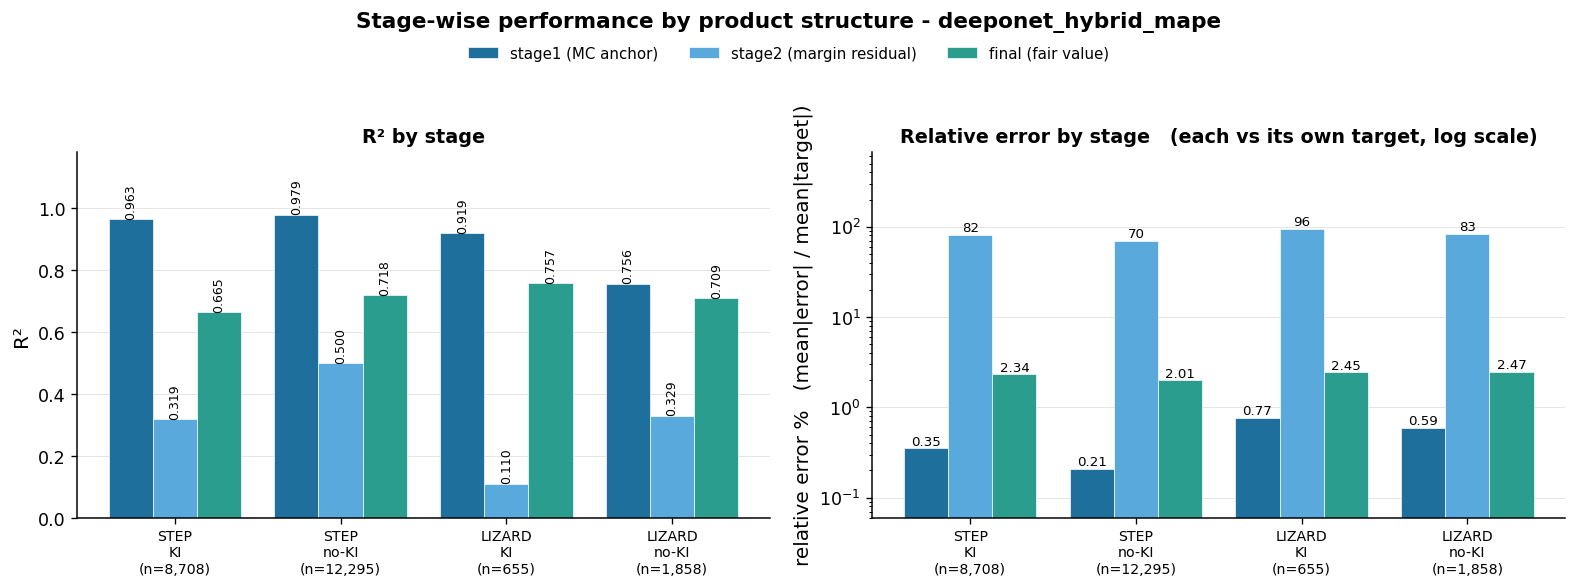

saved -> seg_stage_structure.png


In [11]:
# 그림 8: 상품 구조별 단계 지표 — R² · MAPE
S3 = ST[STAGE_MODEL].reindex(STRUCTS)
XL = [s.replace(" x ", "\n") + f"\n(n={int(v):,})" for s, v in zip(STRUCTS, S3["n"])]
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 5.0))
x = np.arange(len(STRUCTS))

w1 = 0.8 / len(STAGES)
for j, (sname, _t, _p, lab) in enumerate(STAGES):
    v = S3[f"{sname}_R2"].values
    b = ax[0].bar(x + (j - (len(STAGES) - 1) / 2) * w1, v, w1, label=f"{sname} ({lab})",
                  color=_plot._QUAL[j], edgecolor="white", linewidth=0.4)
    for r, val in zip(b, v):
        ax[0].text(r.get_x() + r.get_width() / 2, val, f"{val:.3f}", ha="center",
                   va="bottom" if val >= 0 else "top", fontsize=7.5, rotation=90)
ax[0].set_ylabel("R²"); ax[0].set_title("R² by stage", fontsize=11.5)
ax[0].set_ylim(0, 1.18)

for j, (sname, _t, _p, lab) in enumerate(STAGES):        # 오차도 R² 와 같은 규칙: 자기 타깃 분모
    v = S3[f"{sname}_RELown"].values
    b = ax[1].bar(x + (j - (len(STAGES) - 1) / 2) * w1, v, w1, label=f"{sname} ({lab})",
                  color=_plot._QUAL[j], edgecolor="white", linewidth=0.4)
    for r, val in zip(b, v):
        ax[1].text(r.get_x() + r.get_width() / 2, val,
                   f"{val:.2f}" if val < 10 else f"{val:.0f}", ha="center", va="bottom", fontsize=8)
_v = np.concatenate([S3[f"{s_[0]}_RELown"].values for s_ in STAGES])
ax[1].set_yscale("log"); ax[1].set_ylim(max(0.05, _v.min() / 3.5), _v.max() * 7)
ax[1].set_ylabel("relative error %   (mean|error| / mean|target|)")
ax[1].set_title("Relative error by stage   (each vs its own target, log scale)", fontsize=11.5)

for a in ax:
    a.set_xticks(x); a.set_xticklabels(XL, fontsize=8.5)
    a.grid(axis="y", color="#cccccc", lw=0.6, alpha=0.5)
ax[0].axhline(0, color="#444", lw=0.7)
h, l = ax[0].get_legend_handles_labels()
fig.legend(h, l, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.945),
           fontsize=9, frameon=False)
fig.suptitle(f"Stage-wise performance by product structure - {STAGE_MODEL}", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.savefig(fm.image("seg_stage_structure"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("saved ->", fm.image("seg_stage_structure").name)

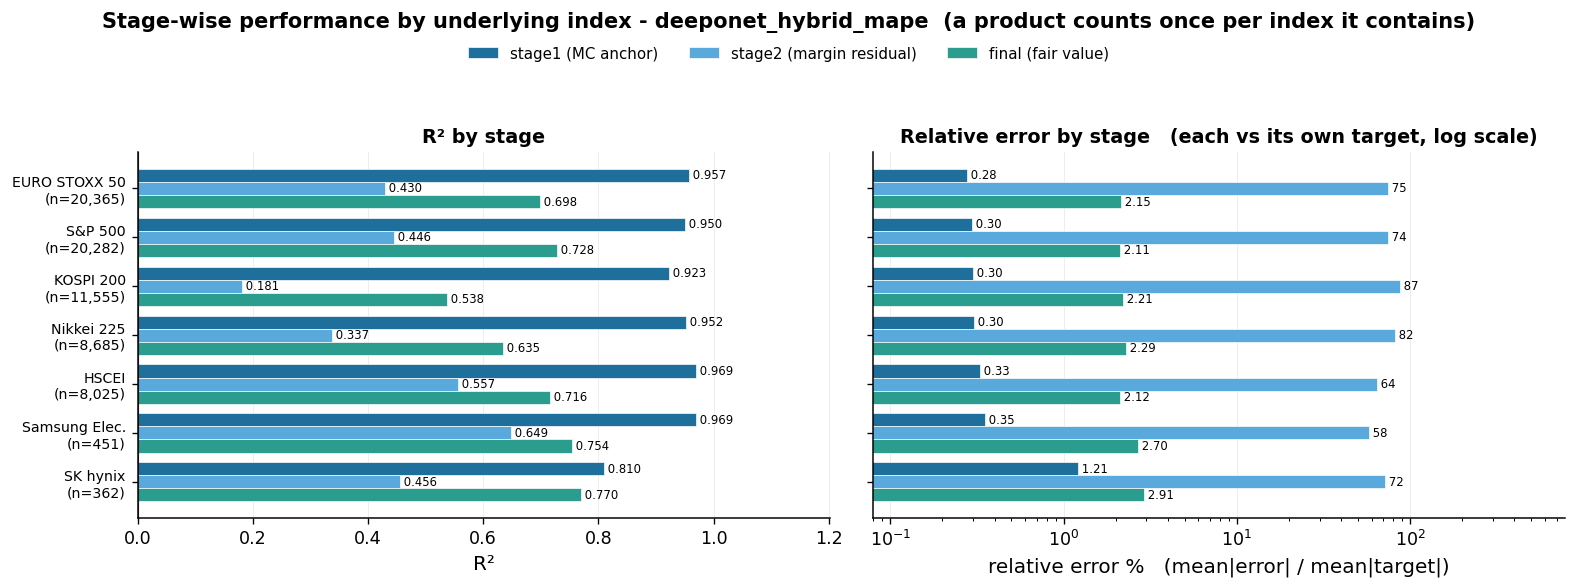

saved -> seg_stage_underlying.png


In [12]:
# 그림 9: 기초자산 지수별 단계 지표 — R² · MAPE
U3 = UT[STAGE_MODEL]
YL = [f"{i}\n(n={int(v):,})" for i, v in zip(U3.index, U3["n"])]
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, max(5.0, 0.56 * len(U3))))
y = np.arange(len(U3))

w1 = 0.8 / len(STAGES)
for j, (sname, _t, _p, lab) in enumerate(STAGES):
    v = U3[f"{sname}_R2"].values
    ax[0].barh(y + (j - (len(STAGES) - 1) / 2) * w1, v, w1, label=f"{sname} ({lab})",
               color=_plot._QUAL[j], edgecolor="white", linewidth=0.4)
    for k, val in enumerate(v):
        ax[0].text(val, y[k] + (j - (len(STAGES) - 1) / 2) * w1, f" {val:.3f}",
                   va="center", fontsize=7)
ax[0].set_xlabel("R²"); ax[0].set_title("R² by stage", fontsize=11.5)
ax[0].margins(x=0.24)

for j, (sname, _t, _p, lab) in enumerate(STAGES):        # 오차도 R² 와 같은 규칙: 자기 타깃 분모
    v = U3[f"{sname}_RELown"].values
    ax[1].barh(y + (j - (len(STAGES) - 1) / 2) * w1, v, w1, label=f"{sname} ({lab})",
               color=_plot._QUAL[j], edgecolor="white", linewidth=0.4)
    for k, val in enumerate(v):
        ax[1].text(val, y[k] + (j - (len(STAGES) - 1) / 2) * w1,
                   f" {val:.2f}" if val < 10 else f" {val:.0f}", va="center", fontsize=7)
_v = np.concatenate([U3[f"{s_[0]}_RELown"].values for s_ in STAGES])
ax[1].set_xscale("log"); ax[1].set_xlim(max(0.05, _v.min() / 3.5), _v.max() * 9)
ax[1].set_xlabel("relative error %   (mean|error| / mean|target|)")
ax[1].set_title("Relative error by stage   (each vs its own target, log scale)", fontsize=11.5)

for a in ax:
    a.set_yticks(y); a.set_yticklabels(YL if a is ax[0] else [], fontsize=8.5)
    a.invert_yaxis()
    a.grid(axis="x", color="#dddddd", lw=0.5, alpha=0.6)
ax[0].axvline(0, color="#444", lw=0.7)
h, l = ax[0].get_legend_handles_labels()
fig.legend(h, l, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.945),
           fontsize=9, frameon=False)
fig.suptitle(f"Stage-wise performance by underlying index - {STAGE_MODEL}"
             "  (a product counts once per index it contains)", fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.savefig(fm.image("seg_stage_underlying"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("saved ->", fm.image("seg_stage_underlying").name)

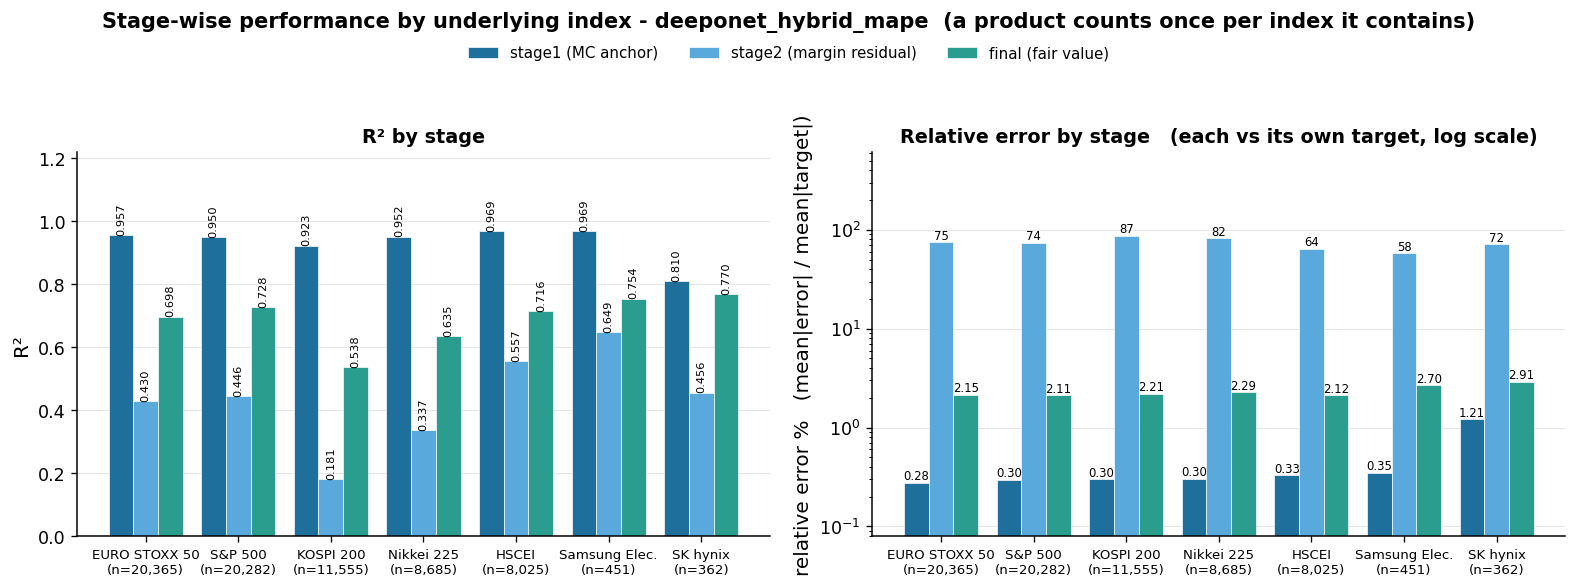

saved -> seg_stage_underlying_vertical.png


In [13]:
# 그림 9b: 기초자산 지수별 단계 지표 — 세로 막대 버전 (그림 9 의 가로판과 같은 수치)
U3 = UT[STAGE_MODEL]
XL = [f"{i}\n(n={int(v):,})" for i, v in zip(U3.index, U3["n"])]
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 5.0))
x = np.arange(len(U3))

w1 = 0.8 / len(STAGES)
for j, (sname, _t, _p, lab) in enumerate(STAGES):
    v = U3[f"{sname}_R2"].values
    b = ax[0].bar(x + (j - (len(STAGES) - 1) / 2) * w1, v, w1, label=f"{sname} ({lab})",
                  color=_plot._QUAL[j], edgecolor="white", linewidth=0.4)
    for r, val in zip(b, v):
        ax[0].text(r.get_x() + r.get_width() / 2, val, f"{val:.3f}", ha="center",
                   va="bottom" if val >= 0 else "top", fontsize=6.8, rotation=90)
ax[0].set_ylabel("R²"); ax[0].set_title("R² by stage", fontsize=11.5)
ax[0].set_ylim(0, 1.22)

for j, (sname, _t, _p, lab) in enumerate(STAGES):        # 오차도 R² 와 같은 규칙: 자기 타깃 분모
    v = U3[f"{sname}_RELown"].values
    b = ax[1].bar(x + (j - (len(STAGES) - 1) / 2) * w1, v, w1, label=f"{sname} ({lab})",
                  color=_plot._QUAL[j], edgecolor="white", linewidth=0.4)
    for r, val in zip(b, v):
        ax[1].text(r.get_x() + r.get_width() / 2, val,
                   f"{val:.2f}" if val < 10 else f"{val:.0f}", ha="center", va="bottom", fontsize=7)
_v = np.concatenate([U3[f"{s_[0]}_RELown"].values for s_ in STAGES])
ax[1].set_yscale("log"); ax[1].set_ylim(max(0.05, _v.min() / 3.5), _v.max() * 7)
ax[1].set_ylabel("relative error %   (mean|error| / mean|target|)")
ax[1].set_title("Relative error by stage   (each vs its own target, log scale)", fontsize=11.5)

for a in ax:
    a.set_xticks(x); a.set_xticklabels(XL, fontsize=8)
    a.grid(axis="y", color="#cccccc", lw=0.6, alpha=0.5)
ax[0].axhline(0, color="#444", lw=0.7)

h, l = ax[0].get_legend_handles_labels()
fig.legend(h, l, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.945),
           fontsize=9, frameon=False)
fig.suptitle(f"Stage-wise performance by underlying index - {STAGE_MODEL}"
             "  (a product counts once per index it contains)", fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.savefig(fm.image("seg_stage_underlying_vertical"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("saved ->", fm.image("seg_stage_underlying_vertical").name)

## 5-5. R² 해부 — 리자드가 R² 가 높은 건 오차가 작아서가 아니라 분산이 커서

`R² = 1 − SS_res/SS_tot = 1 − (RMSE/σ_y)²` 다. **분자(오차)와 분모(타깃 분산)를 분리**해서 보면
LIZARD×KI 의 높은 R²(0.763)가 어디서 오는지 드러난다.

- LIZARD×KI 와 STEP×KI 의 **RMSE 는 288 vs 290원으로 사실상 같다**(분자 동일).
- 그런데 공정가 표준편차는 **592 vs 498원**(분모가 19% 넓다).
- 그래서 R² 만 0.763 vs 0.661 로 벌어진다. MAPE 로 보면 오히려 2.42% vs 2.35% 로 리자드가 나쁘다.

④ 패널의 **반사실(counterfactual)** 이 결정적이다 — 각 구조의 오차를 그대로 두고 분모만
전체 OOS 공통 분산으로 바꿔 평가하면 순위가 뒤집힌다. 세그먼트 비교는 R² 가 아니라
**MAPE·RMSE 로 해야 한다**는 뜻이다.

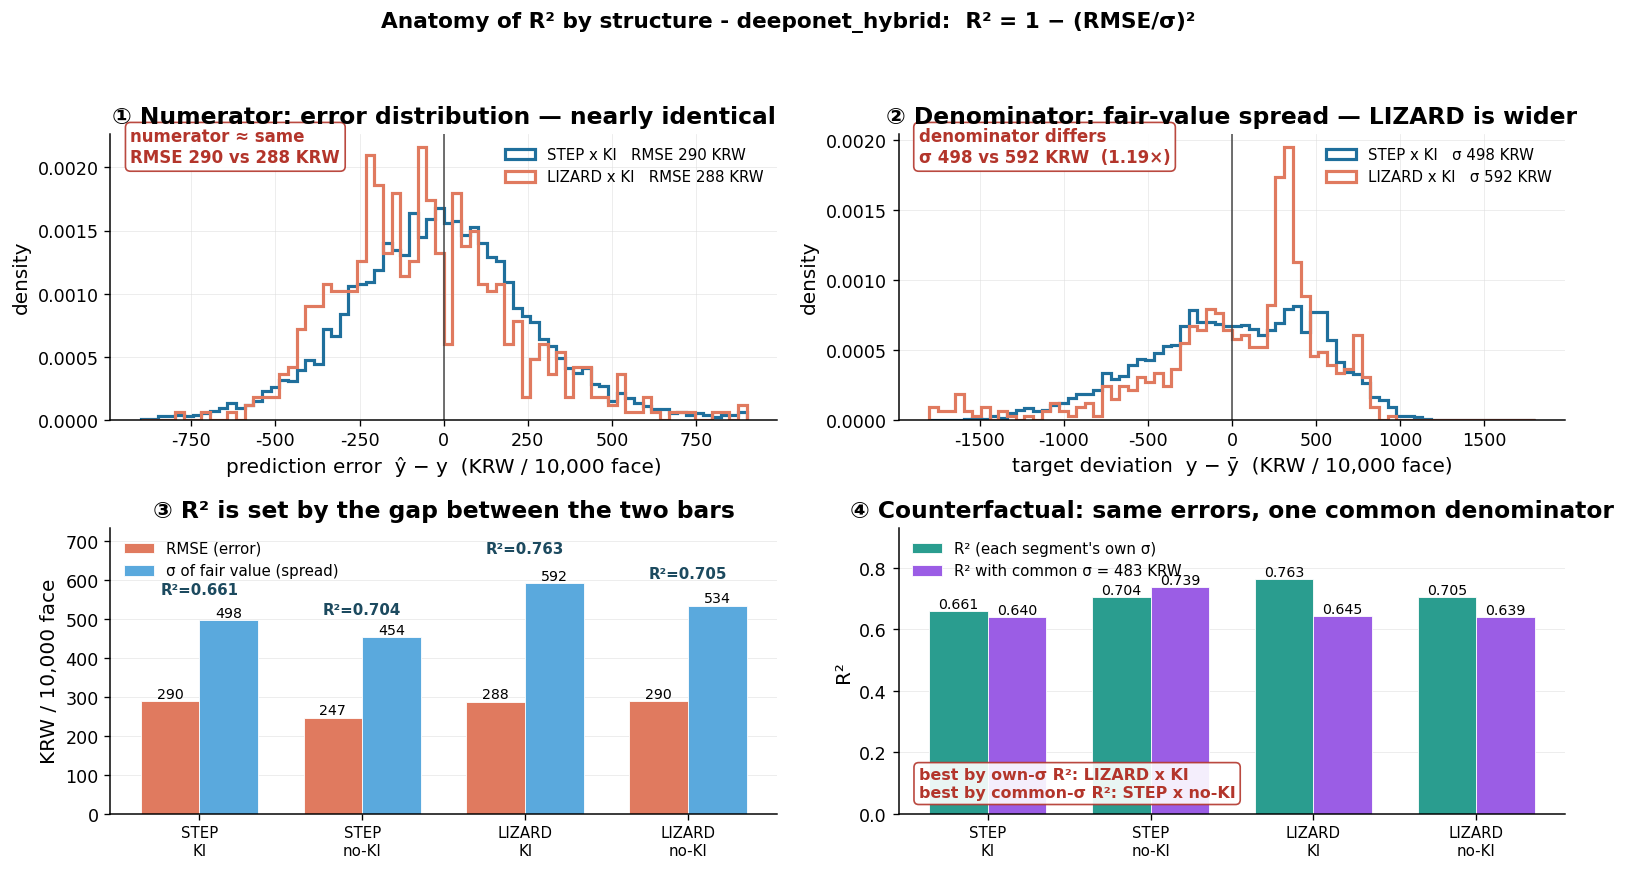

struct                n    RMSE       σ  RMSE/σ      R²    R²(공통σ)   MAPE%
STEP x KI         8,708   289.7   497.6   0.582  +0.661     +0.640   2.355
STEP x no-KI     12,295   246.8   453.6   0.544  +0.704     +0.739   2.076
LIZARD x KI         655   288.0   591.8   0.487  +0.763     +0.645   2.421
LIZARD x no-KI    1,858   290.2   534.0   0.543  +0.705     +0.639   2.492

공통 σ (전체 OOS) = 483.0 KRW
saved -> seg_r2_variance_anatomy.png


In [14]:
# 그림 10: R² 해부 (2×2) — 분자(오차)는 같고 분모(분산)가 다르다
d = M[M.model == BEST]
PAIR = ["STEP x KI", "LIZARD x KI"]          # RMSE 가 거의 같은 쌍 (대비가 가장 선명)
COL = {"STEP x KI": "#1f6f9c", "LIZARD x KI": "#e07a5f"}
RD, GY = "#b3352b", "#777777"

st = {}
for s in STRUCTS:
    g = d[d.struct == s]
    e = (g.y_pred - g.y_true).values * FACE
    dev = (g.y_true - g.y_true.mean()).values * FACE
    st[s] = dict(n=len(g), err=e, dev=dev, rmse=float(np.sqrt((e ** 2).mean())),
                 sd=float(np.sqrt((dev ** 2).mean())),
                 mape=float((np.abs(g.y_pred - g.y_true) / g.y_true).mean() * 100),
                 r2=1 - (e ** 2).mean() / (dev ** 2).mean())
sd_all = float((d.y_true - d.y_true.mean()).std(ddof=0) * FACE)     # 전체 OOS 공통 분모

fig, ax = plt.subplots(2, 2, figsize=(13.333, 7.4))

# ① 분자: 잔차 분포 — 두 구조가 거의 겹친다
a = ax[0, 0]
for s in PAIR:
    a.hist(st[s]["err"], bins=70, range=(-900, 900), histtype="step", linewidth=1.9,
           color=COL[s], density=True, label=f"{s}   RMSE {st[s]['rmse']:.0f} KRW")
a.axvline(0, color="#444", lw=0.9)
a.text(0.03, 0.90, f"numerator ≈ same\nRMSE {st[PAIR[0]]['rmse']:.0f} vs {st[PAIR[1]]['rmse']:.0f} KRW",
       transform=a.transAxes, fontsize=10, fontweight="bold", color=RD,
       bbox=dict(boxstyle="round", fc="white", ec=RD, alpha=0.9))
a.set_xlabel("prediction error  ŷ − y  (KRW / 10,000 face)"); a.set_ylabel("density")
a.set_title("① Numerator: error distribution — nearly identical")
a.legend(fontsize=9, loc="upper right"); a.grid(color="#dddddd", lw=0.5, alpha=0.6)

# ② 분모: 타깃 편차 분포 — 리자드가 더 넓다
a = ax[0, 1]
for s in PAIR:
    a.hist(st[s]["dev"], bins=70, range=(-1800, 1800), histtype="step", linewidth=1.9,
           color=COL[s], density=True, label=f"{s}   σ {st[s]['sd']:.0f} KRW")
a.axvline(0, color="#444", lw=0.9)
r = st[PAIR[1]]["sd"] / st[PAIR[0]]["sd"]
a.text(0.03, 0.90, f"denominator differs\nσ {st[PAIR[0]]['sd']:.0f} vs {st[PAIR[1]]['sd']:.0f} KRW  ({r:.2f}×)",
       transform=a.transAxes, fontsize=10, fontweight="bold", color=RD,
       bbox=dict(boxstyle="round", fc="white", ec=RD, alpha=0.9))
a.set_xlabel("target deviation  y − ȳ  (KRW / 10,000 face)"); a.set_ylabel("density")
a.set_title("② Denominator: fair-value spread — LIZARD is wider")
a.legend(fontsize=9, loc="upper right"); a.grid(color="#dddddd", lw=0.5, alpha=0.6)

# ③ 네 구조: RMSE 와 σ 를 나란히 (+ R² 라벨)
a = ax[1, 0]
x = np.arange(len(STRUCTS)); w = 0.36
rm = [st[s]["rmse"] for s in STRUCTS]; sg = [st[s]["sd"] for s in STRUCTS]
a.bar(x - w / 2, rm, w, label="RMSE (error)", color="#e07a5f", edgecolor="white", linewidth=0.5)
a.bar(x + w / 2, sg, w, label="σ of fair value (spread)", color="#5aa9dd", edgecolor="white", linewidth=0.5)
for i, s in enumerate(STRUCTS):
    a.text(i - w / 2, rm[i], f"{rm[i]:.0f}", ha="center", va="bottom", fontsize=8.5)
    a.text(i + w / 2, sg[i], f"{sg[i]:.0f}", ha="center", va="bottom", fontsize=8.5)
    a.text(i, max(rm[i], sg[i]) * 1.13, f"R²={st[s]['r2']:.3f}", ha="center", fontsize=9,
           fontweight="bold", color="#1c4a5f")
a.set_xticks(x); a.set_xticklabels([s.replace(" x ", "\n") for s in STRUCTS], fontsize=9)
a.set_ylabel("KRW / 10,000 face"); a.margins(y=0.24)
a.set_title("③ R² is set by the gap between the two bars")
a.legend(fontsize=9, loc="upper left"); a.grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6)

# ④ 반사실: 분모만 공통(전체 OOS σ)으로 바꿔 평가하면 순위가 뒤집힌다
a = ax[1, 1]
r2_own = [st[s]["r2"] for s in STRUCTS]
r2_cmn = [1 - (st[s]["rmse"] / sd_all) ** 2 for s in STRUCTS]
a.bar(x - w / 2, r2_own, w, label="R² (each segment's own σ)", color="#2a9d8f",
      edgecolor="white", linewidth=0.5)
a.bar(x + w / 2, r2_cmn, w, label=f"R² with common σ = {sd_all:.0f} KRW", color="#9b5de5",
      edgecolor="white", linewidth=0.5)
for i in range(len(STRUCTS)):
    a.text(i - w / 2, r2_own[i], f"{r2_own[i]:.3f}", ha="center", va="bottom", fontsize=8.5)
    a.text(i + w / 2, r2_cmn[i], f"{r2_cmn[i]:.3f}", ha="center", va="bottom", fontsize=8.5)
best_own = STRUCTS[int(np.argmax(r2_own))]; best_cmn = STRUCTS[int(np.argmax(r2_cmn))]
a.text(0.03, 0.06, f"best by own-σ R²: {best_own}\nbest by common-σ R²: {best_cmn}",
       transform=a.transAxes, fontsize=9.5, fontweight="bold", color=RD,
       bbox=dict(boxstyle="round", fc="white", ec=RD, alpha=0.9))
a.set_xticks(x); a.set_xticklabels([s.replace(" x ", "\n") for s in STRUCTS], fontsize=9)
a.set_ylabel("R²"); a.margins(y=0.22)
a.set_title("④ Counterfactual: same errors, one common denominator")
a.legend(fontsize=9, loc="upper left"); a.grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6)

fig.suptitle(f"Anatomy of R² by structure - {BEST}:  R² = 1 − (RMSE/σ)²",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(fm.image("seg_r2_variance_anatomy"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()

print(f"{'struct':16s} {'n':>6} {'RMSE':>7} {'σ':>7} {'RMSE/σ':>7} {'R²':>7} {'R²(공통σ)':>10} {'MAPE%':>7}")
for s in STRUCTS:
    k = st[s]
    print(f"{s:16s} {k['n']:6,} {k['rmse']:7.1f} {k['sd']:7.1f} {k['rmse']/k['sd']:7.3f} "
          f"{k['r2']:+7.3f} {1-(k['rmse']/sd_all)**2:+10.3f} {k['mape']:7.3f}")
print(f"\n공통 σ (전체 OOS) = {sd_all:.1f} KRW")
print("saved ->", fm.image("seg_r2_variance_anatomy").name)

## 5-6. KOSPI200 이 들어가면 왜 성능이 낮게 보이나 — 상관·변동성 관점

지수별 판(그림 5·9)에서 `KS200` 의 최종 R² 가 **0.538 로 가장 낮다**. 원인을 **변동성**과 **상관**으로 분해한다.

- **변동성은 원인이 아니다.** KS200 의 180일 역사변동성은 **16.6%** 로 GSPC(16.4%) 와 사실상 같고
  STOXX50E(18.3%)·N225(19.8%)·HSCE(23.9%) 보다 오히려 **낮다**. 바스켓 `sig_eff` 도 0.235 vs 0.238 로 차이가 없다.
- **상관이 원인이다.** KS200 은 아시아 지수와 강하게 붙어 있다 — HSCE **0.57** · N225 **0.59** · HSI **0.59**.
  반면 GSPC 는 아시아와 거의 무상관(0.20)이다. 그래서 KS200 을 넣은 바스켓의 평균 상관은 **0.312**,
  안 넣은 바스켓은 0.287 이다(OOS 표본 기준. 전량 기준으로는 0.358 vs 0.344).
- **상관이 높으면 worst-of 의 분산이 줄어든다.** 세 자산이 같이 움직일수록 "가장 나쁜 하나"가 극단으로
  벌어질 여지가 작다. 그 결과 공정가가 **더 높고(0.938 vs 0.923) 더 좁게 뭉친다(σ 407 vs 499원)**.
- **R² 는 그 좁아진 분산으로 나눈다.** 실제 오차는 RMSE 277 vs 252원, MAPE **2.22% vs 2.16%** 로 거의 같은데
  분모가 18% 좁아 R² 만 0.538 vs 0.744 로 벌어진다. 공통 분모(전체 OOS σ=483원)로 다시 재면
  **0.672 vs 0.727** — 격차가 0.206 에서 **0.055** 로 줄어든다.

- **표본 전체에서 같은 관계가 확인된다.** 상품을 바스켓 상관 ρ 6분위로 나누면(그림 11 오른쪽)
  ρ 가 오를수록 **분모 σ 가 550 → 442원(−20%)** 으로 줄고 R² 는 **0.800 → 0.468** 로 떨어진다.
  같은 구간에서 KOSPI200 포함 비중은 49% → 64% 로 오른다. 이 구간 비교에서는 분자(RMSE)도
  246 → 322원(+31%)으로 함께 늘어난다 — 상관이 높은 바스켓은 실제로 조금 더 어렵다.
  다만 KOSPI200 포함/미포함 이라는 축으로만 자르면 분자 차이는 277 vs 252원으로 작다.

**결론**: "KS200 이 들어가면 안 좋다"의 **약 73% 는 R² 분모 착시**다. 남은 27% 는 진짜이고
`STEP×KI` 한 칸에 몰려 있다(MAPE 2.62% vs 2.15%). 세그먼트 비교는 5-5 와 같은 이유로 **MAPE·RMSE 로 해야 한다**.

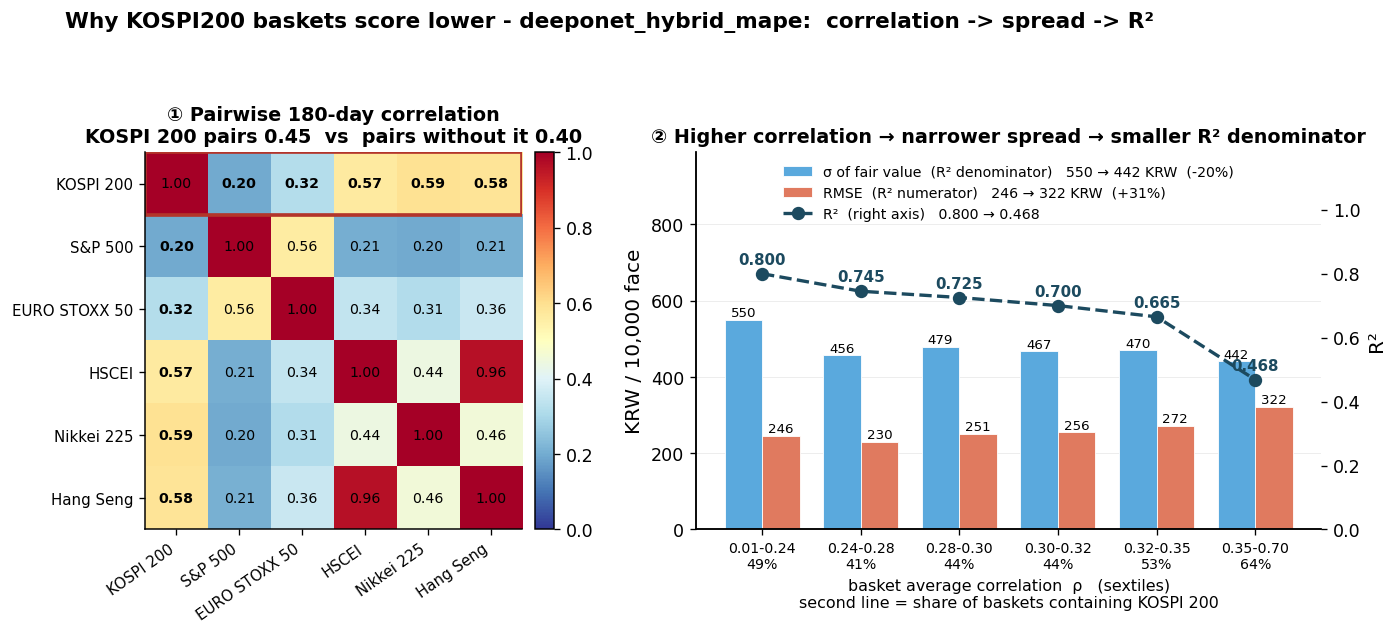

=== ρ 구간별 (R² = 1 - (RMSE/σ)²) ===
   lo    hi   rho    n    ks    RMSE      SD    R2  MAPE
0.011 0.238 0.193 3920 0.489 245.923 549.609 0.800 2.039
0.238 0.277 0.259 3929 0.411 230.354 456.148 0.745 1.939
0.277 0.305 0.291 3909 0.437 251.149 479.198 0.725 2.057
0.305 0.324 0.314 3920 0.443 255.797 467.039 0.700 2.166
0.324 0.353 0.337 3918 0.528 272.172 470.200 0.665 2.239
0.353 0.696 0.404 3920 0.640 322.223 441.903 0.468 2.704

=== KOSPI200 포함 여부 (공통 σ = 483원) ===
        group   rho     n    RMSE      SD    R2  MAPE  R2_common
 KOSPI 200 in 0.312 11555 276.598 406.890 0.538 2.219      0.672
KOSPI 200 out 0.287 11961 252.373 499.255 0.744 2.163      0.727

=== 구조 통제 ===
        struct            KS    n    RMSE      SD    R2  MAPE
   LIZARD x KI  KOSPI 200 in  275 303.523 311.824 0.053 2.447
   LIZARD x KI KOSPI 200 out  380 282.682 649.628 0.811 2.466
LIZARD x no-KI  KOSPI 200 in  930 282.901 463.173 0.627 2.422
LIZARD x no-KI KOSPI 200 out  928 293.529 505.364 0.663 2.519
     STE

In [15]:
# 그림 11: 상관이 높으면 R² 분모(공정가 σ)가 좁아진다 — 히트맵 + ρ 구간 분해
MAIN = ["^KS200", "^GSPC", "^STOXX50E", "^HSCE", "^N225", "^HSI"]
CIN, COUT, RD = "#e07a5f", "#1f6f9c", "#b3352b"


def _logret(t):
    p = fm.CACHE / ("px_" + t.replace("^", "_").replace(".", "_") + ".parquet")
    s = pd.read_parquet(p)["close"].dropna().sort_index()
    return np.log(s[~s.index.duplicated()]).diff()


# 데이터셋과 같은 정의(180일 역사) 로 지수쌍 상관
X = pd.DataFrame({t: _logret(t) for t in MAIN}).sort_index().loc["2015":"2024"]
VOL = (X.rolling(180, min_periods=120).std() * np.sqrt(252)).mean()
_C = X.rolling(180, min_periods=120).corr()
CM = pd.DataFrame([[_C.xs(a, level=1)[b].mean() for b in MAIN] for a in MAIN], index=MAIN, columns=MAIN)

# 상품 단위 (KOSPI200 포함 여부 + 바스켓 평균 상관)
K = M[M.model == STAGE_MODEL].copy()
K["KS"] = np.where((K.udl1 == "^KS200") | (K.udl2 == "^KS200") | (K.udl3 == "^KS200"),
                   "KOSPI 200 in", "KOSPI 200 out")
_x = pd.read_parquet(fm.source())[["item", "rho", "sig_eff"]]
_x["ITEM_CD"] = _x.pop("item").astype(str)
K = K.merge(_x, on="ITEM_CD", how="left")


def _cell(s):
    e = (s.y_pred - s.y_true).values * FACE
    rmse = float(np.sqrt((e ** 2).mean()))
    sd = float((s.y_true - s.y_true.mean()).std(ddof=0) * FACE)
    return dict(n=len(s), RMSE=rmse, SD=sd, R2=1 - (rmse / sd) ** 2,
                MAPE=float((np.abs(e) / (s.y_true.values * FACE)).mean() * 100))


NBIN = 6
K["rho_bin"] = pd.qcut(K.rho, NBIN, duplicates="drop")
B = pd.DataFrame([{"lo": b.left, "hi": b.right, "rho": s.rho.mean(),
                   "ks": float((s.KS == "KOSPI 200 in").mean()), **_cell(s)}
                  for b, s in K.groupby("rho_bin", observed=True)])

fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 5.4))

# ① 지수쌍 상관 — KOSPI200 은 아시아와 강하게 붙어 있다
a = ax[0]
im = a.imshow(CM.values, cmap="RdYlBu_r", vmin=0, vmax=1)
a.set_xticks(range(len(MAIN))); a.set_yticks(range(len(MAIN)))
a.set_xticklabels([uname(t) for t in MAIN], fontsize=9, rotation=35, ha="right")
a.set_yticklabels([uname(t) for t in MAIN], fontsize=9)
for i in range(len(MAIN)):
    for j in range(len(MAIN)):
        a.text(j, i, f"{CM.values[i,j]:.2f}", ha="center", va="center", fontsize=8.5,
               fontweight="bold" if (i == 0 or j == 0) and i != j else "normal")
a.add_patch(plt.Rectangle((-0.5, -0.5), len(MAIN), 1, fill=False, ec=RD, lw=2.2))
_o = [t for t in MAIN if t != "^KS200"]
_ks = float(CM.loc["^KS200", _o].mean())
_no = float(np.mean([CM.loc[p, q] for i, p in enumerate(_o) for q in _o[i + 1:]]))
a.set_title(f"① Pairwise 180-day correlation\n"
            f"KOSPI 200 pairs {_ks:.2f}  vs  pairs without it {_no:.2f}", fontsize=11.5)
fig.colorbar(im, ax=a, fraction=0.046, pad=0.02)

# ② 상관이 오를수록 R² 분모(공정가 σ)가 좁아진다
a = ax[1]
xb = np.arange(len(B)); w = 0.38


def _delta(v):                                   # 첫 구간 → 마지막 구간 변화
    return f"{v.iloc[0]:.0f} → {v.iloc[-1]:.0f} KRW  ({v.iloc[-1]/v.iloc[0]-1:+.0%})"


b1 = a.bar(xb - w / 2, B.SD, w, color="#5aa9dd", edgecolor="white", linewidth=0.5,
           label=f"σ of fair value  (R² denominator)   {_delta(B.SD)}")
b2 = a.bar(xb + w / 2, B.RMSE, w, color="#e07a5f", edgecolor="white", linewidth=0.5,
           label=f"RMSE  (R² numerator)   {_delta(B.RMSE)}")
for r, v in list(zip(b1, B.SD)) + list(zip(b2, B.RMSE)):
    a.text(r.get_x() + r.get_width() / 2, v, f"{v:.0f}", ha="center", va="bottom", fontsize=8)
a.set_ylabel("KRW / 10,000 face"); a.set_ylim(0, B.SD.max() * 1.80)
a.set_xticks(xb)
a.set_xticklabels([f"{lo:.2f}-{hi:.2f}\n{k:.0%}" for lo, hi, k in zip(B.lo, B.hi, B.ks)],
                  fontsize=8.5)
a.set_xlabel("basket average correlation  ρ   (sextiles)\n"
             "second line = share of baskets containing KOSPI 200", fontsize=9.5)
a.grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6)

a2 = a.twinx()
a2.plot(xb, B.R2, "o--", color="#1c4a5f", lw=2.0, ms=7,
        label=f"R²  (right axis)   {B.R2.iloc[0]:.3f} → {B.R2.iloc[-1]:.3f}")
for i, v in enumerate(B.R2):
    a2.text(xb[i], v + 0.030, f"{v:.3f}", ha="center", fontsize=9, fontweight="bold", color="#1c4a5f")
a2.set_ylabel("R²"); a2.set_ylim(0, 1.18); a2.grid(False)

h1, l1 = a.get_legend_handles_labels(); h2, l2 = a2.get_legend_handles_labels()
a.legend(h1 + h2, l1 + l2, fontsize=8.5, loc="upper center", framealpha=0.95)
a.set_title("② Higher correlation → narrower spread → smaller R² denominator", fontsize=11.5)

fig.suptitle(f"Why KOSPI200 baskets score lower - {STAGE_MODEL}:  correlation -> spread -> R²",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(fm.image("seg_ks200_correlation"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()

# 표: ρ 구간 / KOSPI200 포함 여부 / 구조 통제
B.round(3).to_csv(fm.stat("seg_rho_bins"), index=False)
print("=== ρ 구간별 (R² = 1 - (RMSE/σ)²) ===")
print(B[["lo", "hi", "rho", "n", "ks", "RMSE", "SD", "R2", "MAPE"]].round(3).to_string(index=False))

sd_K = float((K.y_true - K.y_true.mean()).std(ddof=0) * FACE)
print(f"\n=== KOSPI200 포함 여부 (공통 σ = {sd_K:.0f}원) ===")
rows = []
for g, s in K.groupby("KS"):
    c = _cell(s)
    rows.append(dict(group=g, rho=s.rho.mean(), **c, R2_common=1 - (c["RMSE"] / sd_K) ** 2))
KS_G = pd.DataFrame(rows)
print(KS_G.round(3).to_string(index=False))

rows = []
for (st_, g), s in K.groupby(["struct", "KS"]):
    if len(s) >= 100:
        rows.append(dict(struct=st_, KS=g, **_cell(s)))
KS_T = pd.DataFrame(rows)
KS_T.to_csv(fm.stat("seg_ks200"), index=False)
print("\n=== 구조 통제 ===")
print(KS_T.round(3).to_string(index=False))
print(f"\n지수별 180일 역사변동성(%): "
      f"{ {uname(t): round(v*100, 2) for t, v in VOL.sort_values().items()} }")
print("saved ->", fm.image("seg_ks200_correlation").name, "|",
      fm.stat("seg_ks200").name, "|", fm.stat("seg_rho_bins").name)

## 5-7. 요약


In [16]:
# 요약 표 (구조 × 모델 R²) + 저장물 목록
piv = S.pivot(index="struct", columns="model", values="R2").reindex(STRUCTS).round(4)
print("=== 구조별 R² ===")
print(piv.to_string())
print("\n=== 기초자산 지수별 R² (대표 모델) ===")
print(T[["ticker", "n", "R2", "MAPE", "BiasKRW"]].round(4).to_string(index=False))
print("\nsaved images ->", [p.name for p in sorted(fm.IMAGE.glob("seg_*.png"))])
print("saved stats  ->", [p.name for p in sorted(fm.STAT.glob("seg_*.csv"))])

=== 구조별 R² ===
model           bench_xgboost  deeponet_hybrid  deeponet_hybrid_l1  deeponet_hybrid_mape  xgb_hybrid
struct                                                                                              
STEP x KI              0.1772           0.6610              0.6600                0.6646      0.6522
STEP x no-KI           0.4613           0.7041              0.7169                0.7184      0.7135
LIZARD x KI            0.2693           0.7632              0.7667                0.7572      0.7850
LIZARD x no-KI         0.2395           0.7047              0.7006                0.7086      0.6779

=== 기초자산 지수별 R² (대표 모델) ===
   ticker     n     R2   MAPE    BiasKRW
^STOXX50E 20365 0.6888 2.1950   8.470500
    ^GSPC 20282 0.7206 2.1516  15.174900
   ^KS200 11555 0.5162 2.2746  -9.353500
    ^N225  8685 0.6229 2.3443  -9.801800
    ^HSCE  8025 0.7168 2.1205 -21.594299
005930.KS   451 0.7529 2.7281  55.501701
000660.KS   362 0.7830 2.8046  35.205601

saved images -> ['seg